In [1]:
import os
PROJECT_DIR = '/teamspace/studios/this_studio'
csv_path = os.path.join(PROJECT_DIR, 'RecGym.csv')
if not os.path.isfile(csv_path):
    raise FileNotFoundError(f'RecGym.csv not found at {csv_path}')
print(f'PROJECT_DIR : {PROJECT_DIR}')
print('RecGym.csv  : FOUND')


PROJECT_DIR : /teamspace/studios/this_studio
RecGym.csv  : FOUND


# Hybrid CNN + Dilated Self-Attention for Gym Workout Recognition

**Author-exact replication** of the 10-fold leave-one-user-out (LOUO) cross-validation pipeline.

**Platform:** Lightning AI (RTX 6000)

**Key settings (all from author's code):**

| Parameter | Value |
|---|---|
| Conv filters F1 | 32 |
| Depth multiplier D | 4 |
| Conv kernel size | 20 |
| TCN kernel size | 3 |
| TCN dropout | 0.1 |
| TCN dilation (stage 2) | Fixed at 2 |
| Epochs | 1000 (no early stopping) |
| LR decay | ×0.5 every 200 epochs |
| Runs per fold | 3 (best kept) |
| Windowing | 80 samples, stride 80 (no overlap) |
| Scaling | None (raw sensor values) |
| Class weights | Hardcoded (author values) |

---


## 1. Imports


In [2]:
!pip install seaborn --quiet

import os, time, math, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import (accuracy_score, cohen_kappa_score, f1_score,
                             confusion_matrix, classification_report)
from sklearn.utils import shuffle

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
print(f'Device  : {device}')


PyTorch : 2.8.0+cu128
CUDA    : True
GPU     : NVIDIA H100 80GB HBM3
Device  : cuda


---
## 2. Split RecGym Dataset by Position

The author trains **one position at a time**, using separate CSV files:
- `Deep_wrist_All.csv`
- `Deep_leg_All.csv`
- `Deep_pocket_All.csv`

This cell reads `RecGym.csv`, converts string workout labels to integer codes (1–12, alphabetical),
renames `Subject` → `Object` to match the author's column convention, and saves three
position-specific CSVs in the same format the author's preprocessing expects.


In [3]:
# # =============================================
# # Split RecGym.csv → per-position CSVs
# # =============================================
# df_full = pd.read_csv(os.path.join(PROJECT_DIR, "RecGym.csv"))
# df_full = df_full.dropna()

# print(f"Full dataset: {len(df_full):,} rows")
# print(f"Subjects : {sorted(df_full['Subject'].unique())}")
# print(f"Positions: {df_full['Position'].unique().tolist()}")
# print(f"Workouts : {sorted(df_full['Workout'].unique())}")

# # ── Integer encoding: alphabetical order → 1..12 ─────────────────────────
# # After subtracting 1 in load_data_Gym, these become 0..11,
# # matching classes_labels index exactly.
# workout_classes = sorted(df_full['Workout'].unique())
# workout_to_int = {name: idx + 1 for idx, name in enumerate(workout_classes)}
# print(f"\nWorkout → integer mapping:")
# for name, code in workout_to_int.items():
#     print(f"  {name:15s} → {code:2d}  (after -1 → class {code-1})")

# df_full['Workout'] = df_full['Workout'].map(workout_to_int)

# # ── Rename Subject → Object (author convention) ──────────────────────────
# df_full = df_full.rename(columns={'Subject': 'Object'})

# # ── Keep only the columns the author's load_data_Gym needs ───────────────
# # After set_index('Object'), reset_index(), drop(['Object']),
# # the remaining columns are: Workout, A_x, A_y, A_z, G_x, G_y, G_z, C_1
# keep_cols = ['Object', 'Position', 'Workout',
#              'A_x', 'A_y', 'A_z', 'G_x', 'G_y', 'G_z', 'C_1']
# keep_cols = [c for c in keep_cols if c in df_full.columns]
# df_full = df_full[keep_cols]

# # ── Split by position and save ────────────────────────────────────────────
# position_map = {
#     'wrist':  'Deep_wrist_All.csv',
#     'leg':    'Deep_leg_All.csv',
#     'pocket': 'Deep_pocket_All.csv'
# }

# for pos, filename in position_map.items():
#     df_pos = df_full[df_full['Position'] == pos].copy()
#     df_pos = df_pos.drop(columns=['Position'])  # author drops Position
#     save_path = os.path.join(PROJECT_DIR, filename)
#     df_pos.to_csv(save_path, index=False)
#     n_subjects = df_pos['Object'].nunique()
#     print(f"\n{filename}: {len(df_pos):,} rows, {n_subjects} subjects")
#     print(f"  Saved → {save_path}")
#     print(f"  Workout distribution:")
#     print(f"  {df_pos['Workout'].value_counts().sort_index().to_dict()}")

# print("\nDataset split complete.")


---
## 3. Preprocessing (Author-Exact)

Direct port of the author's `preprocess.py`:
- `fold()`: LOUO split using pandas `.loc` indexing
- `load_data_Gym()`: stride-80 windowing, `most_common` labeling, label -= 1, no scaling
- `get_data()`: shuffle train, reshape to (N, 1, 80, C), one-hot encode


In [4]:
# =============================================
# Author's preprocessing — exact port
# =============================================

def most_common(lst):
    """Return the most common element in a list (author's majority-vote labeling)."""
    return max(set(lst), key=lst.count)


def fold(n, data):
    """LOUO fold: subject n is test, rest are train."""
    index = [x for x in range(1, 11)]
    index.pop(n - 1)
    train = data.loc[index, :]
    test = data.loc[[n], :]
    return train, test


def load_data_Gym(data_path, subject, dataset, sensor="combine"):
    """
    Author's exact load_data_Gym from preprocess.py.
    Stride = 80 (no overlap), no StandardScaler, most_common labeling,
    labels -= 1 to convert from 1-based to 0-based.
    *Includes fix to drop trailing rows that don't fit the 80-step window*
    """
    data_session = pd.read_csv(data_path)
    data_session = pd.DataFrame(data_session)

    data_session = data_session.set_index("Object")

    print("Fold =", subject)
    train, test = fold(subject, data_session)

    train = train.reset_index()
    test = test.reset_index()

    drop_cols = ["LocalSerie", "Win_Num", "Win_In_Num", "Object",
                 "Day", "Workout_time", "Position", "Session"]
    drop_cols = [c for c in drop_cols if c in train.columns]
    train = train.drop(drop_cols, axis=1)
    test = test.drop(drop_cols, axis=1)

    # Sensor column selection
    if sensor == "cap":
        X_train = train["C_1"].to_numpy()
        X_test = test["C_1"].to_numpy()
        channel = 1
    elif sensor == "imu":
        X_train = train[["A_x", "A_y", "A_z", "G_x", "G_y", "G_z"]].to_numpy()
        X_test = test[["A_x", "A_y", "A_z", "G_x", "G_y", "G_z"]].to_numpy()
        channel = 6
    elif sensor == "combine":
        X_train = train[["A_x", "A_y", "A_z", "G_x", "G_y", "G_z", "C_1"]].to_numpy()
        X_test = test[["A_x", "A_y", "A_z", "G_x", "G_y", "G_z", "C_1"]].to_numpy()
        channel = 7

    # --- THE FIX: Truncate arrays to exact multiples of 80 ---
    train_len = (X_train.shape[0] // 80) * 80
    test_len  = (X_test.shape[0] // 80) * 80

    X_train = X_train[:train_len]
    X_test  = X_test[:test_len]

    # Majority-vote labels per window (stride = 80, no overlap)
    y_train = np.array([])
    y_test = np.array([])

    # Loop using the truncated lengths so we don't grab partial windows
    for i in range(0, train_len, 80):
        y_train = np.append(y_train, most_common(
            list(train.iloc[i:(i + 80), 0].to_numpy().ravel())))

    for i in range(0, test_len, 80):
        y_test = np.append(y_test, most_common(
            list(test.iloc[i:(i + 80), 0].to_numpy().ravel())))

    X_train = X_train.reshape(-1, 80, channel)
    print("X_train shape:", X_train.shape)

    y_train = y_train.reshape(-1) - 1
    print("y_train shape:", y_train.shape)

    X_test = X_test.reshape(-1, 80, channel)
    print("X_test shape:", X_test.shape)

    y_test = y_test.reshape(-1) - 1
    print("y_test shape:", y_test.shape)
    print("Unique test labels:", np.unique(y_test))

    unique_values, counts = np.unique(y_train, return_counts=True)
    for value, count in zip(unique_values, counts):
        print(f"  class {int(value)}: {int(count)} windows")

    return X_train, y_train, X_test, y_test

def get_data(path, subject, dataset, sensor="combine", isShuffle=True):
    """
    Author's exact get_data from preprocess.py.
    Shuffles train, reshapes to (N,1,80,C), one-hot encodes.
    """
    X_train, y_train, X_test, y_test = load_data_Gym(
        path, subject, dataset, sensor=sensor)

    if isShuffle:
        X_train, y_train = shuffle(X_train, y_train, random_state=42)

    N_tr, N_ch, T = X_train.shape
    X_train = X_train.reshape(N_tr, 1, N_ch, T)
    n_cls = int(max(y_train.max(), y_test.max())) + 1
    y_train_onehot = np.eye(n_cls)[y_train.astype(int)]

    N_tr, N_ch, T = X_test.shape
    X_test = X_test.reshape(N_tr, 1, N_ch, T)
    y_test_onehot = np.eye(n_cls)[y_test.astype(int)]

    return X_train, y_train, y_train_onehot, X_test, y_test, y_test_onehot


---
## 4. Multi-Head Self-Attention Block (Author-Exact)


In [5]:
# =============================================
# MHA block — PyTorch equivalent of author's
# mha_block(key_dim=8, num_heads=4, dropout=0.1)
# =============================================

class MHABlock(nn.Module):
    """
    Matches Keras MultiHeadAttention(key_dim=8, num_heads=4).
    Keras projects Q,K,V to key_dim*num_heads=32 internally.
    """
    def __init__(self, input_dim, key_dim=8, num_heads=4, attn_dropout=0.1):
        super().__init__()
        inner_dim = key_dim * num_heads  # 32
        self.num_heads = num_heads
        self.key_dim = key_dim
        self.scale = key_dim ** -0.5

        self.ln = nn.LayerNorm(input_dim, eps=1e-6)
        self.Wq = nn.Linear(input_dim, inner_dim)
        self.Wk = nn.Linear(input_dim, inner_dim)
        self.Wv = nn.Linear(input_dim, inner_dim)
        self.Wo = nn.Linear(inner_dim, input_dim)
        self.attn_drop = nn.Dropout(attn_dropout)
        self.out_drop = nn.Dropout(0.3)  # author's hardcoded 0.3

    def forward(self, x):
        # x: (N, T, C)
        residual = x
        x = self.ln(x)
        B, T, _ = x.shape
        Q = self.Wq(x).view(B, T, self.num_heads, self.key_dim).transpose(1, 2)
        K = self.Wk(x).view(B, T, self.num_heads, self.key_dim).transpose(1, 2)
        V = self.Wv(x).view(B, T, self.num_heads, self.key_dim).transpose(1, 2)
        attn = (Q @ K.transpose(-2, -1)) * self.scale
        attn = self.attn_drop(torch.softmax(attn, dim=-1))
        out = (attn @ V).transpose(1, 2).reshape(B, T, -1)
        out = self.out_drop(self.Wo(out))
        return out + residual  # skip connection


---
## 5. Model Architecture (Author-Exact)

Ported directly from the author's `models.py`:
- `Conv_block_`: Temporal Conv2D → DepthwiseConv2D → Pointwise Conv2D
- `DI_block_`: Two-stage dilated TCN (dilation 1 → 2, both hardcoded)
- `Post_Fusion`: Dual-branch CNN → sliding-window attention → TCN → average logits


In [6]:
# =============================================
# Conv_block_ — PyTorch equivalent
# Conv2D(F1,(kL,1)) → LN → ELU
# → Depthwise(1,in_ch,D) → LN → ELU → Drop
# → Conv2D(F2,(10,1)) → LN → ELU → Drop
#
# Input:  (N, 1, 80, in_chans)  — channels-first
# Output: (N, F2, 80, 1)
# =============================================

class ConvBlock(nn.Module):
    def __init__(self, F1, D, kernLength, in_chans, dropout=0.1):
        super().__init__()
        F2 = F1 * D
        self.conv1 = nn.Conv2d(1, F1, (kernLength, 1), padding='same', bias=True)
        self.ln1 = nn.LayerNorm(F1)
        self.dw = nn.Conv2d(F1, F2, (1, in_chans), groups=F1, bias=True)
        self.ln2 = nn.LayerNorm(F2)
        self.drop1 = nn.Dropout(dropout)
        self.conv3 = nn.Conv2d(F2, F2, (10, 1), padding='same', bias=True)
        self.ln3 = nn.LayerNorm(F2)
        self.drop2 = nn.Dropout(dropout)

    def forward(self, x):
        # x: (N, 1, 80, in_chans)
        x = self.conv1(x)                       # (N, F1, 80, in_chans)
        x = F.elu(self.ln1(x.permute(0,2,3,1)).permute(0,3,1,2))
        x = self.dw(x)                          # (N, F2, 80, 1)
        x = self.drop1(F.elu(self.ln2(x.permute(0,2,3,1)).permute(0,3,1,2)))
        x = self.conv3(x)                       # (N, F2, 80, 1)
        x = self.drop2(F.elu(self.ln3(x.permute(0,2,3,1)).permute(0,3,1,2)))
        return x


In [7]:
# =============================================
# DI_block_ — PyTorch equivalent
# Stage 1: dilation=1, Stage 2: dilation=2
# Input/Output format: (N, C, T) channels-first
# =============================================

class CausalConv1d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1):
        super().__init__()
        self.pad_len = dilation * (kernel_size - 1)
        self.conv = nn.Conv1d(in_ch, out_ch, kernel_size, dilation=dilation, bias=True)
        nn.init.kaiming_uniform_(self.conv.weight, nonlinearity='linear')  # he_uniform

    def forward(self, x):
        x = F.pad(x, (self.pad_len, 0))
        return self.conv(x)


class DIBlock(nn.Module):
    def __init__(self, in_channels, filters, kernel_size, dropout, activation='elu'):
        super().__init__()
        Act = nn.ELU if activation == 'elu' else nn.ReLU

        # Stage 1: dilation = 1
        self.s1_conv1 = CausalConv1d(in_channels, filters, kernel_size, dilation=1)
        self.s1_bn1   = nn.BatchNorm1d(filters)
        self.s1_act1  = Act()
        self.s1_drop1 = nn.Dropout(dropout)
        self.s1_conv2 = CausalConv1d(filters, filters, kernel_size, dilation=1)
        self.s1_bn2   = nn.BatchNorm1d(filters)
        self.s1_act2  = Act()
        self.s1_drop2 = nn.Dropout(dropout)
        self.use_res1x1 = (in_channels != filters)
        if self.use_res1x1:
            self.res_conv = nn.Conv1d(in_channels, filters, 1, bias=True)
        self.s1_act_out = Act()

        # Stage 2: dilation = 2 (hardcoded)
        self.s2_conv1 = CausalConv1d(filters, filters, kernel_size, dilation=2)
        self.s2_bn1   = nn.BatchNorm1d(filters)
        self.s2_act1  = Act()
        self.s2_drop1 = nn.Dropout(dropout)
        self.s2_conv2 = CausalConv1d(filters, filters, kernel_size, dilation=2)
        self.s2_bn2   = nn.BatchNorm1d(filters)
        self.s2_act2  = Act()
        self.s2_drop2 = nn.Dropout(dropout)
        self.s2_act_out = Act()

    def forward(self, x):
        # Stage 1
        out = self.s1_drop1(self.s1_act1(self.s1_bn1(self.s1_conv1(x))))
        out = self.s1_drop2(self.s1_act2(self.s1_bn2(self.s1_conv2(out))))
        res = self.res_conv(x) if self.use_res1x1 else x
        out = self.s1_act_out(out + res)
        # Stage 2
        s2 = self.s2_drop1(self.s2_act1(self.s2_bn1(self.s2_conv1(out))))
        s2 = self.s2_drop2(self.s2_act2(self.s2_bn2(self.s2_conv2(s2))))
        out = self.s2_act_out(s2 + out)
        return out


In [8]:
# =============================================
# Post_Fusion — PyTorch equivalent
# Dual-branch CNN → sliding-window MHA → TCN → average logits
# =============================================

class PostFusion(nn.Module):
    def __init__(self, n_classes=12, in_chans=7, in_samples=80, n_windows=4,
                 F1=16, D=2, kernelSize=64, dropout=0.1,
                 di_kernelSize=4, di_filters=32, di_dropout=0.3,
                 di_activation='elu'):
        super().__init__()
        self.n_windows = n_windows
        F2 = F1 * D
        concat_dim = F2 * 2  # IMU + Cap branches

        self.conv_imu = ConvBlock(F1, D, kernelSize, in_chans=6, dropout=dropout)
        self.conv_cap = ConvBlock(F1, D, kernelSize, in_chans=1, dropout=dropout)

        # Each sliding window has its OWN attention, TCN, dense (like Keras functional API)
        # GRU before self-attention (one per sliding window)
        self.gru_blocks = nn.ModuleList([
            nn.GRU(input_size=concat_dim, hidden_size=128,
                    num_layers=1, batch_first=True, dropout=0.0)
            for _ in range(n_windows)
        ])
        self.mha_blocks = nn.ModuleList([
            MHABlock(128) for _ in range(n_windows)])
        self.di_blocks = nn.ModuleList([
            DIBlock(128, di_filters, di_kernelSize,
                    di_dropout, di_activation) for _ in range(n_windows)])
        self.output_denses = nn.ModuleList([
            nn.Linear(di_filters, n_classes) for _ in range(n_windows)])

    def forward(self, x):
        # x: (N, 1, 80, 7) — same shape as Keras input
        x_imu = x[:, :, :, 0:6]   # (N, 1, 80, 6)
        x_cap = x[:, :, :, -1:]   # (N, 1, 80, 1)

        b_imu = self.conv_imu(x_imu)  # (N, F2, 80, 1)
        b_cap = self.conv_cap(x_cap)  # (N, F2, 80, 1)

        block1 = torch.cat([b_imu, b_cap], dim=1)  # (N, 2*F2, 80, 1)
        block1 = block1.squeeze(-1)                 # (N, 2*F2, 80)
        block1 = block1.permute(0, 2, 1)            # (N, 80, 2*F2)

        T = block1.shape[1]
        sw_outputs = []
        for i in range(self.n_windows):
            st  = i
            end = T - self.n_windows + i + 1
            win = block1[:, st:end, :]           # (N, T', 256)
            win, _ = self.gru_blocks[i](win)     # (N, T', 128)
            win = self.mha_blocks[i](win)         # (N, T', 128)
            win = win.permute(0, 2, 1)            # (N, 128, T')
            win = self.di_blocks[i](win)          # (N, 32, T')
            win = win[:, :, -1]                   # (N, 32)
            sw_outputs.append(self.output_denses[i](win))

        avg_logits = torch.stack(sw_outputs, dim=0).mean(dim=0)
        return avg_logits  # (N, n_classes) raw logits


In [9]:
# =============================================
# getModel — author's exact hyperparameters
# F1=32, D=4, kernelSize=20, di_kernelSize=3,
# di_filters=32, di_dropout=0.1, di_activation='elu'
# =============================================

def getModel(dataset_conf):
    model = PostFusion(
        n_classes     = dataset_conf['n_classes'],
        in_chans      = dataset_conf['n_channels'],
        in_samples    = dataset_conf['in_samples'],
        n_windows     = 4,
        F1            = 32,
        D             = 4,
        kernelSize    = 20,
        dropout       = 0.1,
        di_kernelSize = 3,
        di_filters    = 32,
        di_dropout    = 0.1,
        di_activation = 'elu',
    )
    return model.to(device)

# Quick sanity check
_m = getModel({'n_classes':12, 'n_channels':7, 'in_samples':80})
_o = _m(torch.randn(2, 1, 80, 7, device=device))
print(f'Output shape : {_o.shape}')
print(f'Parameters   : {sum(p.numel() for p in _m.parameters()):,}')
del _m, _o


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/nn/modules/conv.py:543: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1027.)
  return F.conv2d(


Output shape : torch.Size([2, 12])
Parameters   : 1,097,584


---
## 6. Visualization & Evaluation Functions

Based on the author's code with improved labeling:
- `draw_learning_curves`: Train/val accuracy and loss per fold
- `plot_confusion_matrix`: Normalized heatmap + raw counts printed
- `draw_performance_barChart`: Per-subject accuracy / kappa bar chart


In [10]:
# =============================================
# Visualization — author's logic, improved labels
# =============================================

def draw_learning_curves(history, results_path, sub, run):
    """Plot training/validation accuracy and loss curves."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history.history['accuracy'],     label='Train',      linewidth=1.5)
    ax1.plot(history.history['val_accuracy'], label='Validation', linewidth=1.5)
    ax1.set_title(f'Subject {sub} — Run {run} — Accuracy', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Accuracy', fontsize=11)
    ax1.set_xlabel('Epoch', fontsize=11)
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)

    ax2.plot(history.history['loss'],     label='Train',      linewidth=1.5)
    ax2.plot(history.history['val_loss'], label='Validation', linewidth=1.5)
    ax2.set_title(f'Subject {sub} — Run {run} — Loss', fontsize=13, fontweight='bold')
    ax2.set_ylabel('Loss', fontsize=11)
    ax2.set_xlabel('Epoch', fontsize=11)
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(results_path,
        f'learning_curves_sub{sub}_run{run}.png'), dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()


def plot_confusion_matrix(y_true, y_pred, sub, results_path, classes,
                          position_label='', normalize=True, cmap=plt.cm.Blues):
    """Author's confusion matrix with improved labeling."""
    accuracy = accuracy_score(y_true, y_pred)
    F1_note = f1_score(y_true, y_pred, average='macro')
    kappa_val = cohen_kappa_score(y_true, y_pred)

    title = (f"Subject: {sub}  |  Position: {position_label}\n"
             f"Accuracy: {accuracy*100:.2f}%  |  "
             f"Macro F1: {F1_note*100:.2f}%  |  "
             f"Kappa: {kappa_val:.4f}")

    cm = confusion_matrix(y_true, y_pred)

    # ── Print raw counts ──────────────────────────────────────────────────
    print(f"\n{'─'*60}")
    print(f"  Raw Confusion Matrix — Subject {sub} | {position_label}")
    print(f"{'─'*60}")
    present_idx = sorted(set(y_true.astype(int)) | set(y_pred.astype(int)))
    present_labels = [classes[i] for i in present_idx]
    cm_sub = cm[np.ix_(present_idx, present_idx)] if len(present_idx) < len(classes) else cm
    col_w = max(max(len(l) for l in present_labels), 6) + 2
    header = f"{'True/Pred':<{col_w}}" + "".join(f"{l:>{col_w}}" for l in present_labels)
    print(header)
    print("─" * len(header))
    for i, label in enumerate(present_labels):
        row = f"{label:<{col_w}}" + "".join(f"{cm_sub[i,j]:>{col_w}}" for j in range(len(present_labels)))
        print(row)
    print(f"{'─'*60}")

    # ── Normalized heatmap ────────────────────────────────────────────────
    if normalize:
        cm_plot = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    else:
        cm_plot = cm

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(cm_plot, interpolation='nearest', cmap=cmap)
    ax.figure.colorbar(im, ax=ax, shrink=0.8)
    ax.set(xticks=np.arange(cm_plot.shape[1]),
           yticks=np.arange(cm_plot.shape[0]),
           xticklabels=classes, yticklabels=classes,
           title=title,
           ylabel='True Label', xlabel='Predicted Label')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

    fmt = '.2f' if normalize else 'd'
    thresh = cm_plot.max() / 2.
    for i in range(cm_plot.shape[0]):
        for j in range(cm_plot.shape[1]):
            ax.text(j, i, format(cm_plot[i, j], fmt),
                    ha='center', va='center',
                    color='white' if cm_plot[i, j] > thresh else 'black',
                    fontsize=7)
    fig.tight_layout()
    plt.savefig(os.path.join(results_path, f'cm_subject_{sub}.png'),
                dpi=200, bbox_inches='tight')
    plt.show()
    plt.close(fig)

    # ── Classification report ─────────────────────────────────────────────
    print(f"\n--- Classification Report (Subject {sub}) ---")
    target_names = [classes[i] for i in sorted(set(y_true.astype(int)))]
    print(classification_report(y_true, y_pred, target_names=target_names, digits=4))

    return accuracy, F1_note, kappa_val


def draw_performance_barChart(num_sub, metric, label, results_path,
                              position_label=''):
    """Bar chart of per-subject performance."""
    fig, ax = plt.subplots(figsize=(12, 5))
    x = list(range(1, num_sub + 1))
    bars = ax.bar(x, metric, 0.5, label=label, color='steelblue',
                  edgecolor='white')

    # Value labels on bars
    for bar, val in zip(bars, metric):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

    ax.set_ylabel(label, fontsize=12)
    ax.set_xlabel('Subject', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels([f'S{i}' for i in x], fontsize=10)
    ax.set_title(f'{label} per Subject — Position: {position_label}',
                 fontsize=13, fontweight='bold')
    ax.set_ylim([0, 1.1])
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=10)

    plt.tight_layout()
    plt.savefig(os.path.join(results_path, f'barChart_{label}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)


---
## 7. Training Utilities (Author-Exact)


In [11]:
# =============================================
# Author's exact: sample weights, class weights,
# L2 regularization, max_norm constraint
# =============================================

CONV_WEIGHT_DECAY  = 0.009   # author's L2 for conv layers
DENSE_WEIGHT_DECAY = 0.5     # author's L2 for output dense
CONV_MAX_NORM      = 0.8     # author's max_norm constraint

# Author's hardcoded class weights
CLASS_WEIGHT_DICT = {
    0: 17.34, 1: 16.14, 2: 18.45, 3: 18.89,
    4: 15.50, 5:  1.0,  6:  9.79, 7: 46.91,
    8: 12.4,  9: 10.2, 10:  9.14, 11: 9.1
}


def generate_sample_weights(y_onehot, class_weight_dict):
    return np.array([
        class_weight_dict[np.where(row == 1)[0][0]]
        for row in y_onehot
    ], dtype=np.float32)


def compute_l2_reg(model):
    """Matches Keras L2(wd) = wd * sum(w^2) per layer."""
    reg = torch.tensor(0.0, device=device)
    for name, param in model.named_parameters():
        if 'weight' not in name:
            continue
        if 'output_denses' in name:
            reg = reg + DENSE_WEIGHT_DECAY * (param ** 2).sum()
        elif any(k in name for k in ['conv', 'dw', 'res_conv']):
            reg = reg + CONV_WEIGHT_DECAY * (param ** 2).sum()
    return reg


def apply_max_norm(model, max_val=CONV_MAX_NORM):
    """Post-step weight clipping — matches Keras max_norm constraint."""
    with torch.no_grad():
        for name, param in model.named_parameters():
            if 'weight' not in name:
                continue
            if any(k in name for k in ['conv', 'dw', 'res_conv']):
                p_flat = param.view(param.shape[0], -1)
                norms = p_flat.norm(dim=1, keepdim=True)
                desired = torch.clamp(norms, max=max_val)
                scale = desired / (norms + 1e-8)
                param.mul_(scale.view(param.shape[0], *([1]*(param.dim()-1))))


---
## 8. Train & Test Functions (Author-Exact)

Ported from the author's `main_TrainTest.py`:
- **`train()`**: 10-fold LOUO, 3 runs per subject, hardcoded class weights, no early stopping
- **`test()`**: loads best model per subject, evaluates, plots confusion matrices


In [12]:
# =============================================
# train() — PyTorch port of the TF train()
# Same logic: LOUO folds, EarlyStopping(100),
# ModelCheckpoint(val_accuracy), LR decay ×0.5/200
# =============================================

def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X_b, y_b, w_b in loader:
        X_b, y_b, w_b = X_b.to(device), y_b.to(device), w_b.to(device)
        optimizer.zero_grad()
        logits = model(X_b)
        ce = (F.cross_entropy(logits, y_b, reduction='none') * w_b).mean()
        loss = ce + compute_l2_reg(model)
        loss.backward()
        optimizer.step()
        apply_max_norm(model)
        total_loss += ce.item() * X_b.size(0)
        correct += (logits.argmax(1) == y_b).sum().item()
        total += X_b.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, X_t, y_t):
    model.eval()
    logits = model(X_t.to(device))
    loss = F.cross_entropy(logits, y_t.to(device)).item()
    acc = (logits.argmax(1) == y_t.to(device)).float().mean().item()
    return loss, acc


def train(dataset_conf, train_conf, results_path):
    in_exp = time.time()

    best_models_f = open(os.path.join(results_path, 'best_models.txt'), 'w')
    log_f         = open(os.path.join(results_path, 'log.txt'), 'w')

    dataset        = dataset_conf['name']
    n_sub          = dataset_conf['n_sub']
    data_path      = dataset_conf['data_path']
    sensor         = dataset_conf.get('sensor', 'combine')
    position_label = dataset_conf.get('position_label', '')

    batch_size = train_conf['batch_size']
    epochs     = train_conf['epochs']
    lr         = train_conf['lr']
    n_train    = train_conf['n_train']

    acc   = np.zeros((n_sub, n_train))
    kappa = np.zeros((n_sub, n_train))

    for sub in range(n_sub):
        in_sub = time.time()
        print(f'\n{"="*70}')
        print(f'  Subject {sub+1}/{n_sub} — {position_label}')
        print(f'{"="*70}')
        log_f.write(f'\nTraining on subject {sub+1}\n')
        BestSubjAcc = 0
        bestHistory = {}

        X_train, _, y_train_oh, X_test, _, y_test_oh = get_data(
            data_path, sub + 1, dataset, sensor=sensor)

        y_train_int = y_train_oh.argmax(axis=-1).astype(np.int64)
        y_test_int  = y_test_oh.argmax(axis=-1).astype(np.int64)
        sample_w    = generate_sample_weights(y_train_oh, CLASS_WEIGHT_DICT)

        X_test_t = torch.FloatTensor(X_test)
        y_test_t = torch.LongTensor(y_test_int)

        train_ds = TensorDataset(
            torch.FloatTensor(X_train),
            torch.LongTensor(y_train_int),
            torch.FloatTensor(sample_w))
        loader = DataLoader(train_ds, batch_size=batch_size,
                            shuffle=True, num_workers=0, pin_memory=True)

        for run in range(n_train):
            torch.manual_seed(run + 1)
            np.random.seed(run + 1)

            in_run = time.time()
            save_dir = os.path.join(results_path, 'saved_models', f'run-{run+1}')
            os.makedirs(save_dir, exist_ok=True)
            filepath = os.path.join(save_dir, f'subject-{sub+1}.pt')

            model = getModel(dataset_conf)
            if sub == 0 and run == 0:
                print(f'  Parameters: {sum(p.numel() for p in model.parameters()):,}')

            optimizer = torch.optim.Adam(model.parameters(), lr=lr)
            sched = torch.optim.lr_scheduler.StepLR(optimizer, step_size=200, gamma=0.5)

            best_val_acc = 0.0
            patience_counter = 0
            best_val_loss = float('inf')
            history = {'accuracy':[], 'val_accuracy':[], 'loss':[], 'val_loss':[]}

            for epoch in range(epochs):
                t_loss, t_acc = train_one_epoch(model, loader, optimizer)
                v_loss, v_acc = evaluate(model, X_test_t, y_test_t)
                sched.step()

                history['loss'].append(t_loss)
                history['accuracy'].append(t_acc)
                history['val_loss'].append(v_loss)
                history['val_accuracy'].append(v_acc)

                # ModelCheckpoint: save on best val_accuracy
                if v_acc > best_val_acc:
                    best_val_acc = v_acc
                    torch.save(model.state_dict(), filepath)

                # EarlyStopping: monitor val_loss, patience=100
                if v_loss < best_val_loss - 1e-4:
                    best_val_loss = v_loss
                    patience_counter = 0
                else:
                    patience_counter += 1

                # if (epoch + 1) % 100 == 0 or epoch == 0:
                    print(f'    Epoch {epoch+1:4d}/{epochs}  '
                          f't_acc={t_acc:.4f}  v_acc={v_acc:.4f}  '
                          f'best={best_val_acc:.4f}  '
                          f'lr={optimizer.param_groups[0]["lr"]:.2e}')

                if patience_counter >= 100:
                    print(f'    EarlyStopping at epoch {epoch+1}')
                    break

            # Load best weights and evaluate
            model.load_state_dict(torch.load(filepath, weights_only=True))
            model.eval()
            with torch.no_grad():
                preds = model(X_test_t.to(device)).argmax(1).cpu().numpy()
            labels = y_test_int
            acc[sub, run]   = accuracy_score(labels, preds)
            kappa[sub, run] = cohen_kappa_score(labels, preds)

            out_run = time.time()
            info = (f'  S{sub+1} Run{run+1}: '
                    f'{(out_run-in_run)/60:.1f}min  '
                    f'Acc={acc[sub,run]:.4f}  Kappa={kappa[sub,run]:.4f}')
            print(info)
            log_f.write(info + '\n')

            if BestSubjAcc < acc[sub, run]:
                BestSubjAcc = acc[sub, run]
                bestHistory = copy.deepcopy(history)

        best_run = np.argmax(acc[sub, :])
        best_models_f.write(
            f'saved_models/run-{best_run+1}/subject-{sub+1}.pt\n')

        out_sub = time.time()
        info = (f'  Subject {sub+1} BEST run={best_run+1}  '
                f'acc={acc[sub,best_run]:.4f}  '
                f'kappa={kappa[sub,best_run]:.4f}  '
                f'time={((out_sub-in_sub)/60):.1f}min')
        print(info)
        log_f.write(info + '\n')

        if bestHistory:
            class H: pass
            h = H(); h.history = bestHistory
            draw_learning_curves(h, results_path, sub+1, best_run+1)

    out_exp = time.time()
    info = f'\nTotal training: {(out_exp-in_exp)/3600:.1f} hours'
    print(info)
    log_f.write(info + '\n')

    np.savez(os.path.join(results_path, 'perf_allRuns.npz'),
             acc=acc, kappa=kappa)
    best_models_f.close()
    log_f.close()


In [13]:
# =============================================
# test() — PyTorch port
# =============================================

def test(dataset_conf, results_path, allRuns=True):
    log_f = open(os.path.join(results_path, 'log.txt'), 'a')
    best_f = open(os.path.join(results_path, 'best_models.txt'), 'r')
    os.makedirs(os.path.join(results_path, 'test'), exist_ok=True)

    dataset        = dataset_conf['name']
    n_classes      = dataset_conf['n_classes']
    n_sub          = dataset_conf['n_sub']
    data_path      = dataset_conf['data_path']
    sensor         = dataset_conf.get('sensor', 'combine')
    classes_labels = dataset_conf['cl_labels']
    position_label = dataset_conf.get('position_label', '')

    acc_best   = np.zeros(n_sub)
    kappa_best = np.zeros(n_sub)
    f1_best    = np.zeros(n_sub)

    if allRuns:
        perf = np.load(os.path.join(results_path, 'perf_allRuns.npz'))
        acc_all   = perf['acc']
        kappa_all = perf['kappa']

    labels_all = np.array([])
    preds_all  = np.array([])

    for sub in range(n_sub):
        _, _, _, X_test, _, y_test_oh = get_data(
            data_path, sub + 1, dataset, sensor=sensor)
        y_test_int = y_test_oh.argmax(axis=-1).astype(np.int64)

        filepath = best_f.readline().strip()
        model = getModel(dataset_conf)
        model.load_state_dict(torch.load(
            os.path.join(results_path, filepath),
            weights_only=True, map_location=device))
        model.eval()

        with torch.no_grad():
            preds = model(
                torch.FloatTensor(X_test).to(device)
            ).argmax(1).cpu().numpy()
        labels = y_test_int

        acc_best[sub]   = accuracy_score(labels, preds)
        kappa_best[sub] = cohen_kappa_score(labels, preds)
        f1_best[sub]    = f1_score(labels, preds, average='macro')

        plot_confusion_matrix(
            labels, preds, sub+1, results_path, classes_labels,
            position_label=position_label)

        np.save(os.path.join(results_path, 'test',
            f'Y_truth_Sub_{sub+1}.npy'), labels)
        np.save(os.path.join(results_path, 'test',
            f'Y_pred_Sub_{sub+1}.npy'), preds)

        labels_all = np.concatenate([labels_all, labels])
        preds_all  = np.concatenate([preds_all, preds])

        run_num = filepath.split('run-')[1].split('/')[0]
        info = (f'Subject {sub+1}  best_run={run_num}  '
                f'acc={acc_best[sub]:.4f}  '
                f'kappa={kappa_best[sub]:.4f}  '
                f'f1={f1_best[sub]:.4f}')
        if allRuns:
            info += (f'  avg_acc={np.mean(acc_all[sub,:]):.4f}'
                     f'+/-{acc_all[sub,:].std():.4f}')
        print(info)
        log_f.write('\n' + info)

    print(f'\n{"="*70}')
    info = (f'Average of {n_sub} subjects (best runs):\n'
            f'  Accuracy = {np.mean(acc_best):.4f} +/- {np.std(acc_best):.4f}\n'
            f'  Kappa    = {np.mean(kappa_best):.4f} +/- {np.std(kappa_best):.4f}\n'
            f'  Macro F1 = {np.mean(f1_best):.4f} +/- {np.std(f1_best):.4f}')
    if allRuns:
        info += (f'\nAverage of {n_sub}x{acc_all.shape[1]} runs: '
                 f'acc={np.mean(acc_all):.4f}  kappa={np.mean(kappa_all):.4f}')
    print(info)
    log_f.write('\n' + info)

    draw_performance_barChart(n_sub, acc_best, 'Accuracy', results_path, position_label)
    draw_performance_barChart(n_sub, kappa_best, 'Kappa', results_path, position_label)
    draw_performance_barChart(n_sub, f1_best, 'Macro_F1', results_path, position_label)

    plot_confusion_matrix(
        labels_all, preds_all, 'All', results_path, classes_labels,
        position_label=position_label)

    summary = pd.DataFrame({
        'Subject': list(range(1, n_sub+1)),
        'Accuracy': acc_best, 'Kappa': kappa_best, 'Macro_F1': f1_best})
    summary.loc[len(summary)] = ['Mean', np.mean(acc_best),
        np.mean(kappa_best), np.mean(f1_best)]
    summary.loc[len(summary)] = ['Std', np.std(acc_best),
        np.std(kappa_best), np.std(f1_best)]
    sp = os.path.join(results_path, 'evaluation_summary.csv')
    summary.to_csv(sp, index=False)
    print(f'\nSummary saved: {sp}')
    print(summary.to_string(index=False))

    log_f.close()
    best_f.close()


---
## 9. Configuration & Execution

**Author-exact settings.** Change `data_path` and `results_path` to switch positions.

Default: **wrist** (author's primary experiment). Uncomment leg/pocket lines to run those.


In [14]:
# =============================================
# Configuration — author's exact values
# =============================================

dataset     = 'Gym_Cap'
in_samples  = 80
n_channels  = 7
n_sub       = 10
n_classes   = 12
sensor_mode = 'combine'

classes_labels = [
    'Adductor', 'ArmCurl', 'BenchPress', 'LegCurl',
    'LegPress', 'Null', 'Riding', 'RopeSkipping',
    'Running', 'Squat', 'StairClimber', 'Walking'
]

# ── Position (uncomment ONE pair) ────────────────────────────────
# data_path      = os.path.join(PROJECT_DIR, 'Deep_wrist_All.csv')
# position_label = 'Wrist'
# results_suffix = 'results_wrist'

data_path      = os.path.join(PROJECT_DIR, 'Deep_leg_All.csv')
position_label = 'Leg'
results_suffix = 'results_leg'

# data_path      = os.path.join(PROJECT_DIR, 'Deep_pocket_All.csv')
# position_label = 'Pocket'
# results_suffix = 'results_pocket'

results_path = os.path.join(PROJECT_DIR, results_suffix)
os.makedirs(results_path, exist_ok=True)

dataset_conf = {
    'name': dataset, 'n_classes': n_classes, 'cl_labels': classes_labels,
    'n_sub': n_sub, 'n_channels': n_channels, 'in_samples': in_samples,
    'data_path': data_path, 'sensor': sensor_mode,
    'position_label': position_label,
}

train_conf = {
    'batch_size': 256,
    'epochs':     1000,
    'lr':         0.0001,
    'LearnCurves': True,
    'n_train':    1,
}

print(f'Position  : {position_label}')
print(f'Data      : {data_path}')
print(f'Results   : {results_path}')
print(f'Device    : {device}')
print(f'Epochs    : {train_conf["epochs"]} (EarlyStopping patience=100)')
print(f'Runs/fold : {train_conf["n_train"]}')
print(f'LR        : {train_conf["lr"]} x0.5 every 200 epochs')


Position  : Leg
Data      : /teamspace/studios/this_studio/Deep_leg_All.csv
Results   : /teamspace/studios/this_studio/results_leg
Device    : cuda
Epochs    : 1000 (EarlyStopping patience=100)
Runs/fold : 1
LR        : 0.0001 x0.5 every 200 epochs



  Subject 1/10 — Leg


Fold = 1
X_train shape: (16858, 80, 7)
y_train shape: (16858,)
X_test shape: (1596, 80, 7)
y_test shape: (1596,)
Unique test labels: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11.]
  class 0: 490 windows
  class 1: 563 windows
  class 2: 495 windows
  class 3: 491 windows
  class 4: 587 windows
  class 5: 9489 windows
  class 6: 955 windows
  class 7: 180 windows
  class 8: 751 windows
  class 9: 854 windows
  class 10: 991 windows
  class 11: 1012 windows
  Parameters: 1,097,584
    Epoch    2/1000  t_acc=0.1006  v_acc=0.0388  best=0.0445  lr=1.00e-04
    Epoch    4/1000  t_acc=0.0975  v_acc=0.0595  best=0.0883  lr=1.00e-04
    Epoch    5/1000  t_acc=0.1483  v_acc=0.0852  best=0.0883  lr=1.00e-04
    Epoch    8/1000  t_acc=0.2758  v_acc=0.2356  best=0.2356  lr=1.00e-04
    Epoch   12/1000  t_acc=0.5086  v_acc=0.4962  best=0.5025  lr=1.00e-04
    Epoch   16/1000  t_acc=0.6221  v_acc=0.6410  best=0.6410  lr=1.00e-04
    Epoch   17/1000  t_acc=0.6443  v_acc=0.6071  best=0.6410  lr=1.00

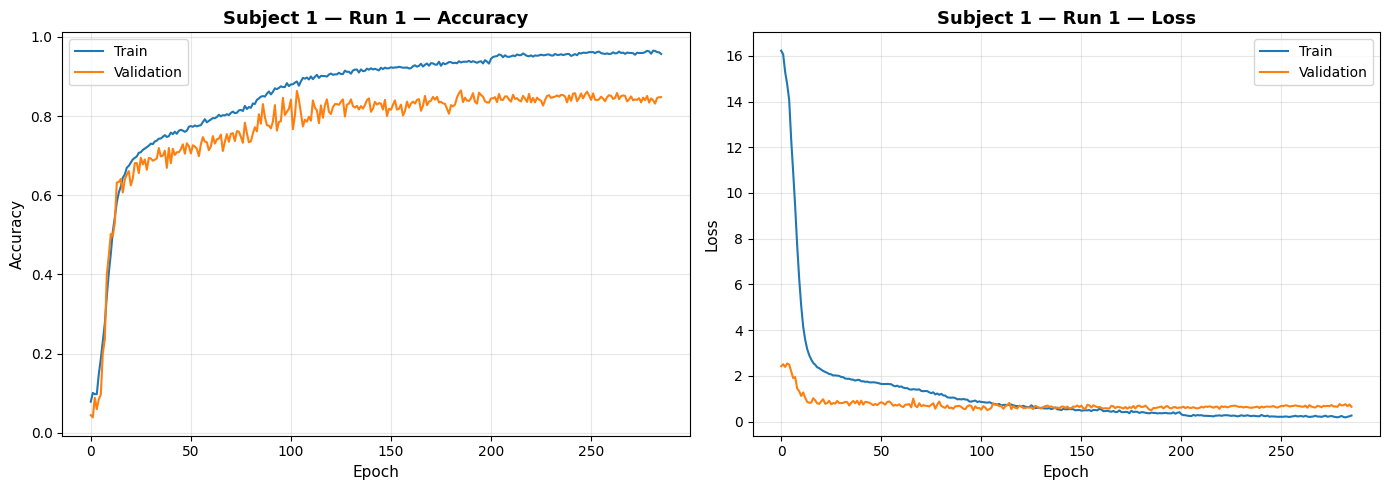


  Subject 2/10 — Leg
Fold = 2
X_train shape: (16057, 80, 7)
y_train shape: (16057,)
X_test shape: (2397, 80, 7)
y_test shape: (2397,)
Unique test labels: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11.]
  class 0: 491 windows
  class 1: 541 windows
  class 2: 454 windows
  class 3: 483 windows
  class 4: 571 windows
  class 5: 8886 windows
  class 6: 930 windows
  class 7: 170 windows
  class 8: 739 windows
  class 9: 848 windows
  class 10: 962 windows
  class 11: 982 windows
    Epoch    2/1000  t_acc=0.0835  v_acc=0.0521  best=0.0521  lr=1.00e-04
    Epoch    6/1000  t_acc=0.1555  v_acc=0.1364  best=0.1448  lr=1.00e-04
    Epoch   11/1000  t_acc=0.4237  v_acc=0.3183  best=0.3279  lr=1.00e-04
    Epoch   15/1000  t_acc=0.6080  v_acc=0.5336  best=0.5686  lr=1.00e-04
    Epoch   18/1000  t_acc=0.6438  v_acc=0.6112  best=0.6608  lr=1.00e-04
    Epoch   19/1000  t_acc=0.6550  v_acc=0.5874  best=0.6608  lr=1.00e-04
    Epoch   21/1000  t_acc=0.6729  v_acc=0.5624  best=0.6783  lr=1.00e-0

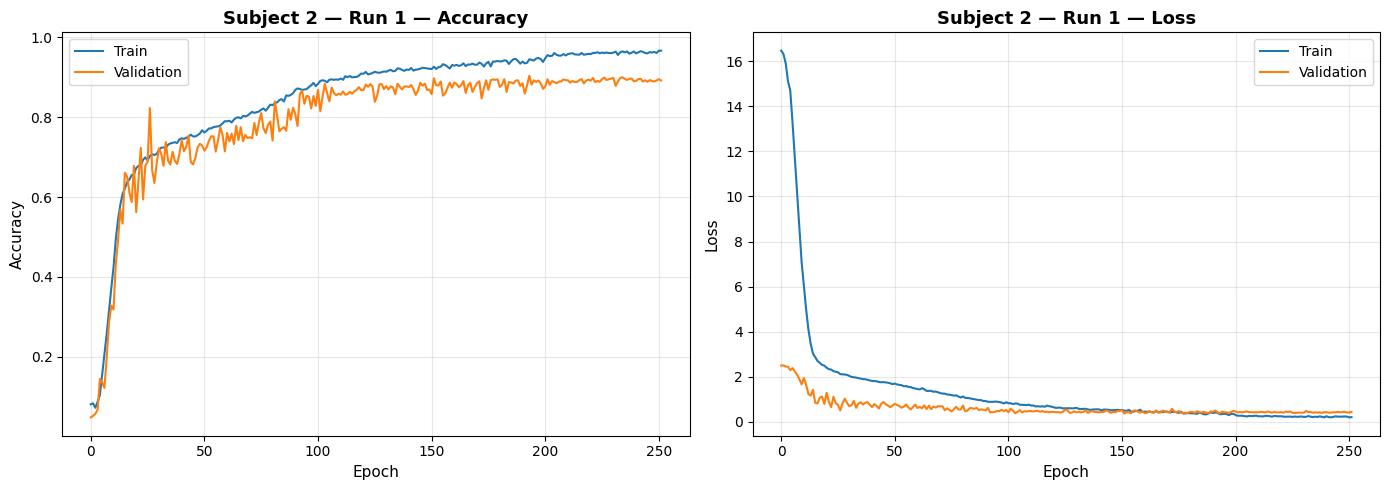


  Subject 3/10 — Leg
Fold = 3
X_train shape: (16441, 80, 7)
y_train shape: (16441,)
X_test shape: (2012, 80, 7)
y_test shape: (2012,)
Unique test labels: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11.]
  class 0: 477 windows
  class 1: 526 windows
  class 2: 488 windows
  class 3: 460 windows
  class 4: 579 windows
  class 5: 9277 windows
  class 6: 919 windows
  class 7: 183 windows
  class 8: 758 windows
  class 9: 842 windows
  class 10: 960 windows
  class 11: 972 windows
    Epoch    2/1000  t_acc=0.0918  v_acc=0.0413  best=0.0969  lr=1.00e-04
    Epoch    3/1000  t_acc=0.1080  v_acc=0.0656  best=0.0969  lr=1.00e-04
    Epoch   13/1000  t_acc=0.5312  v_acc=0.4667  best=0.5557  lr=1.00e-04
    Epoch   14/1000  t_acc=0.5590  v_acc=0.5457  best=0.5557  lr=1.00e-04
    Epoch   15/1000  t_acc=0.5786  v_acc=0.5467  best=0.5557  lr=1.00e-04
    Epoch   19/1000  t_acc=0.6340  v_acc=0.7033  best=0.7068  lr=1.00e-04
    Epoch   21/1000  t_acc=0.6545  v_acc=0.7083  best=0.7311  lr=1.00e-0

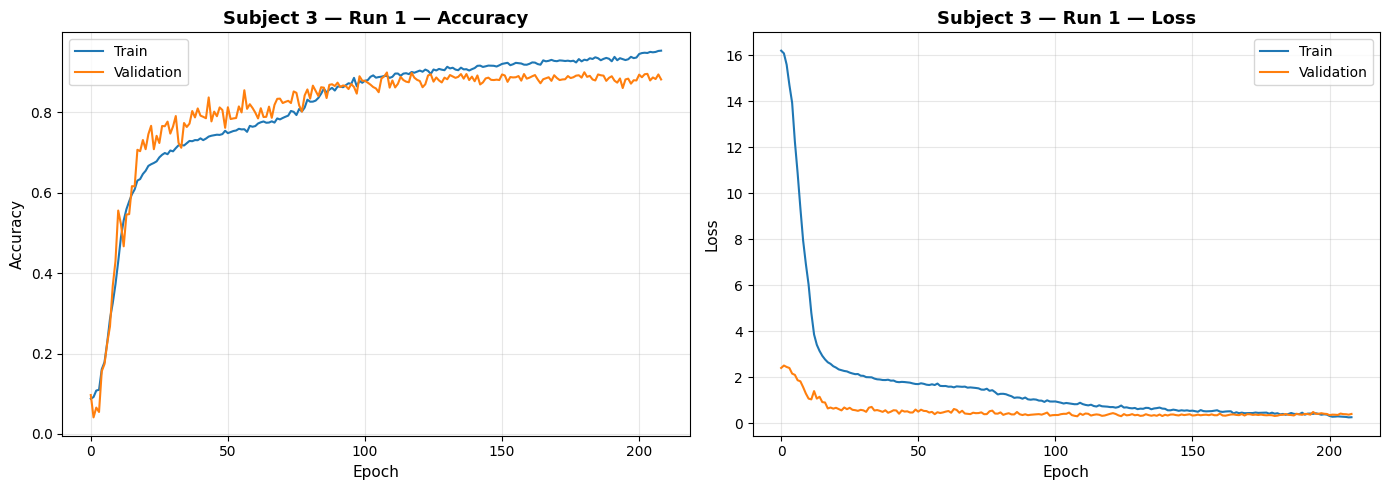


  Subject 4/10 — Leg
Fold = 4
X_train shape: (16816, 80, 7)
y_train shape: (16816,)
X_test shape: (1637, 80, 7)
y_test shape: (1637,)
Unique test labels: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11.]
  class 0: 499 windows
  class 1: 557 windows
  class 2: 486 windows
  class 3: 490 windows
  class 4: 601 windows
  class 5: 9458 windows
  class 6: 936 windows
  class 7: 191 windows
  class 8: 780 windows
  class 9: 845 windows
  class 10: 977 windows
  class 11: 996 windows
    Epoch    2/1000  t_acc=0.0934  v_acc=0.0342  best=0.0629  lr=1.00e-04
    Epoch    3/1000  t_acc=0.1044  v_acc=0.0495  best=0.0629  lr=1.00e-04
    Epoch    4/1000  t_acc=0.1222  v_acc=0.0354  best=0.0629  lr=1.00e-04
    Epoch    7/1000  t_acc=0.2407  v_acc=0.1417  best=0.5009  lr=1.00e-04
    Epoch   11/1000  t_acc=0.4878  v_acc=0.4062  best=0.5009  lr=1.00e-04
    Epoch   14/1000  t_acc=0.5983  v_acc=0.5223  best=0.5638  lr=1.00e-04
    Epoch   15/1000  t_acc=0.6184  v_acc=0.5761  best=0.5761  lr=1.00e-0

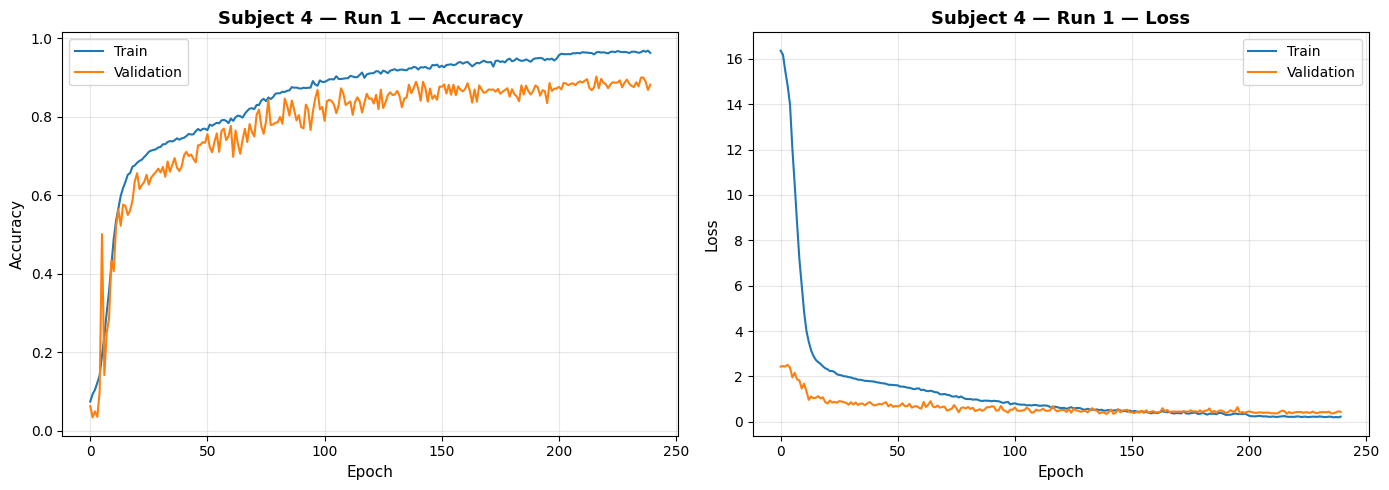


  Subject 5/10 — Leg
Fold = 5
X_train shape: (16554, 80, 7)
y_train shape: (16554,)
X_test shape: (1900, 80, 7)
y_test shape: (1900,)
Unique test labels: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11.]
  class 0: 490 windows
  class 1: 559 windows
  class 2: 492 windows
  class 3: 474 windows
  class 4: 563 windows
  class 5: 9301 windows
  class 6: 926 windows
  class 7: 172 windows
  class 8: 757 windows
  class 9: 866 windows
  class 10: 966 windows
  class 11: 988 windows
    Epoch    3/1000  t_acc=0.0920  v_acc=0.0368  best=0.0653  lr=1.00e-04
    Epoch    7/1000  t_acc=0.2307  v_acc=0.2089  best=0.2089  lr=1.00e-04
    Epoch    8/1000  t_acc=0.2741  v_acc=0.2405  best=0.2405  lr=1.00e-04
    Epoch   11/1000  t_acc=0.4394  v_acc=0.4642  best=0.4732  lr=1.00e-04
    Epoch   12/1000  t_acc=0.4819  v_acc=0.4416  best=0.4732  lr=1.00e-04
    Epoch   18/1000  t_acc=0.6399  v_acc=0.6505  best=0.6647  lr=1.00e-04
    Epoch   19/1000  t_acc=0.6522  v_acc=0.5884  best=0.6647  lr=1.00e-0

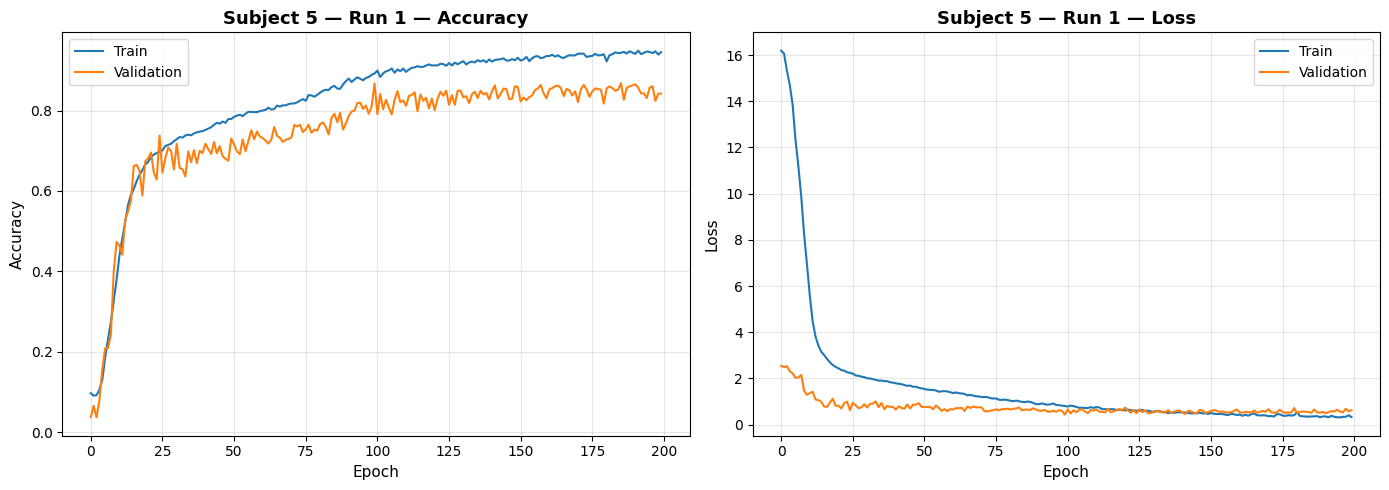


  Subject 6/10 — Leg
Fold = 6
X_train shape: (17072, 80, 7)
y_train shape: (17072,)
X_test shape: (1382, 80, 7)
y_test shape: (1382,)
Unique test labels: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11.]
  class 0: 504 windows
  class 1: 563 windows
  class 2: 515 windows
  class 3: 514 windows
  class 4: 610 windows
  class 5: 9472 windows
  class 6: 990 windows
  class 7: 180 windows
  class 8: 798 windows
  class 9: 876 windows
  class 10: 1015 windows
  class 11: 1035 windows
    Epoch    2/1000  t_acc=0.0792  v_acc=0.0282  best=0.0289  lr=1.00e-04
    Epoch    4/1000  t_acc=0.1003  v_acc=0.0347  best=0.0434  lr=1.00e-04
    Epoch    6/1000  t_acc=0.1801  v_acc=0.1389  best=0.1389  lr=1.00e-04
    Epoch   12/1000  t_acc=0.5183  v_acc=0.4457  best=0.4457  lr=1.00e-04
    Epoch   15/1000  t_acc=0.6173  v_acc=0.5116  best=0.5116  lr=1.00e-04
    Epoch   16/1000  t_acc=0.6358  v_acc=0.4935  best=0.5116  lr=1.00e-04
    Epoch   17/1000  t_acc=0.6507  v_acc=0.4863  best=0.5116  lr=1.00e

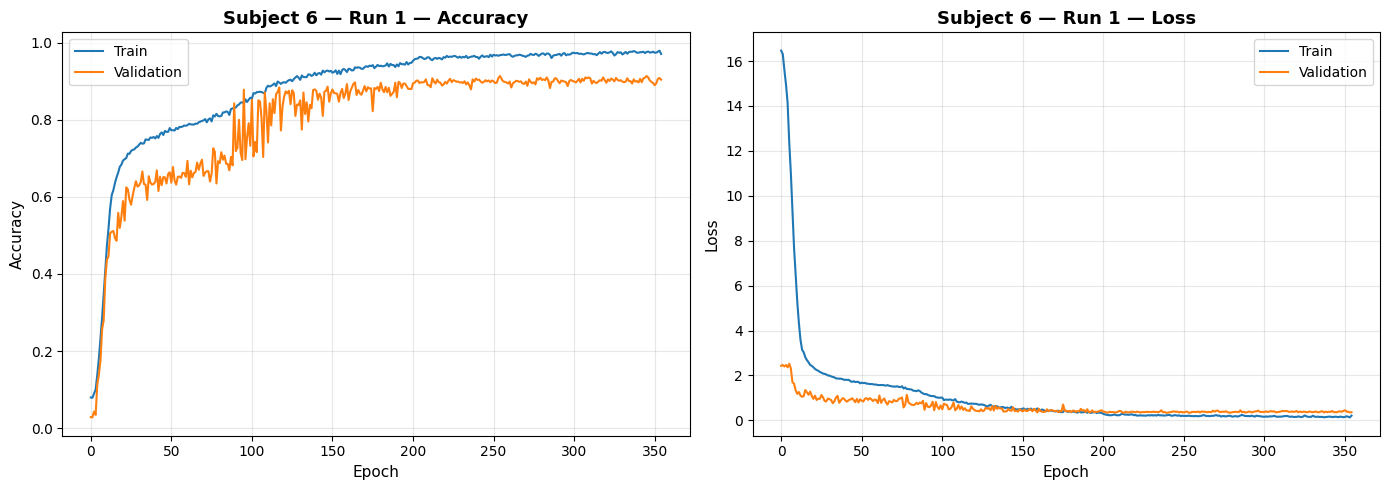


  Subject 7/10 — Leg
Fold = 7
X_train shape: (16335, 80, 7)
y_train shape: (16335,)
X_test shape: (2119, 80, 7)
y_test shape: (2119,)
Unique test labels: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11.]
  class 0: 490 windows
  class 1: 555 windows
  class 2: 492 windows
  class 3: 477 windows
  class 4: 575 windows
  class 5: 9088 windows
  class 6: 920 windows
  class 7: 172 windows
  class 8: 751 windows
  class 9: 867 windows
  class 10: 963 windows
  class 11: 985 windows
    Epoch    6/1000  t_acc=0.1642  v_acc=0.1850  best=0.5715  lr=1.00e-04
    Epoch    7/1000  t_acc=0.2173  v_acc=0.2204  best=0.5715  lr=1.00e-04
    Epoch    8/1000  t_acc=0.2620  v_acc=0.2298  best=0.5715  lr=1.00e-04
    Epoch   12/1000  t_acc=0.5001  v_acc=0.3997  best=0.5715  lr=1.00e-04
    Epoch   13/1000  t_acc=0.5311  v_acc=0.4710  best=0.5715  lr=1.00e-04
    Epoch   14/1000  t_acc=0.5675  v_acc=0.4667  best=0.5715  lr=1.00e-04
    Epoch   15/1000  t_acc=0.5868  v_acc=0.5644  best=0.5715  lr=1.00e-0

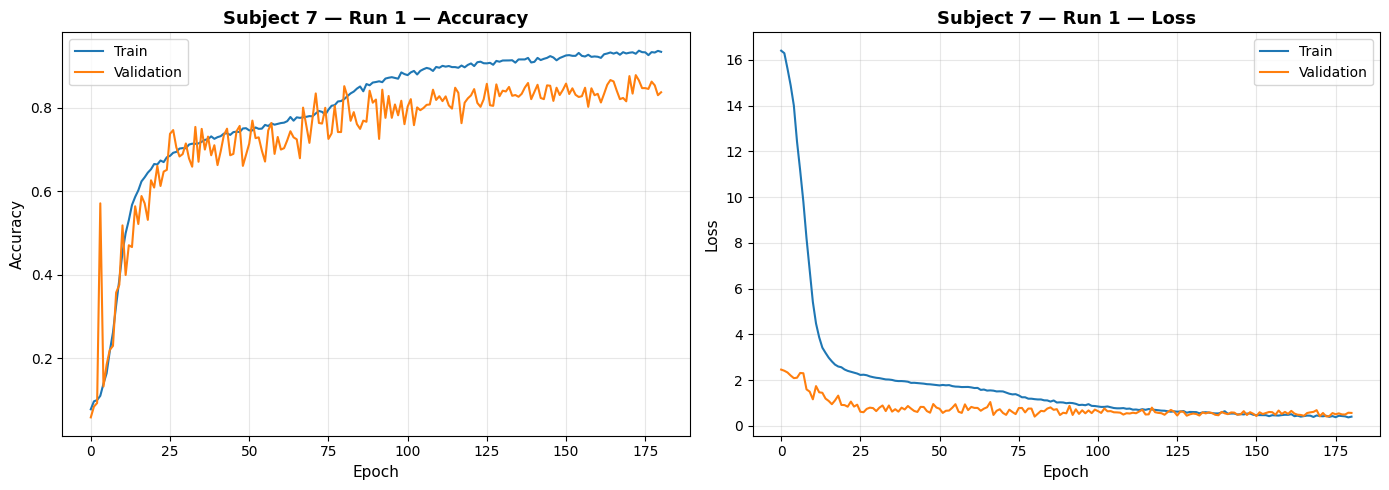


  Subject 8/10 — Leg
Fold = 8
X_train shape: (16548, 80, 7)
y_train shape: (16548,)
X_test shape: (1905, 80, 7)
y_test shape: (1905,)
Unique test labels: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11.]
  class 0: 459 windows
  class 1: 534 windows
  class 2: 479 windows
  class 3: 480 windows
  class 4: 564 windows
  class 5: 9381 windows
  class 6: 918 windows
  class 7: 176 windows
  class 8: 746 windows
  class 9: 858 windows
  class 10: 958 windows
  class 11: 995 windows
    Epoch    3/1000  t_acc=0.0879  v_acc=0.0677  best=0.0677  lr=1.00e-04
    Epoch    4/1000  t_acc=0.1049  v_acc=0.1071  best=0.1071  lr=1.00e-04
    Epoch    8/1000  t_acc=0.2655  v_acc=0.2016  best=0.5276  lr=1.00e-04
    Epoch    9/1000  t_acc=0.3190  v_acc=0.3249  best=0.5276  lr=1.00e-04
    Epoch   13/1000  t_acc=0.5448  v_acc=0.5003  best=0.5601  lr=1.00e-04
    Epoch   14/1000  t_acc=0.5703  v_acc=0.5790  best=0.5790  lr=1.00e-04
    Epoch   16/1000  t_acc=0.6149  v_acc=0.6310  best=0.6357  lr=1.00e-0

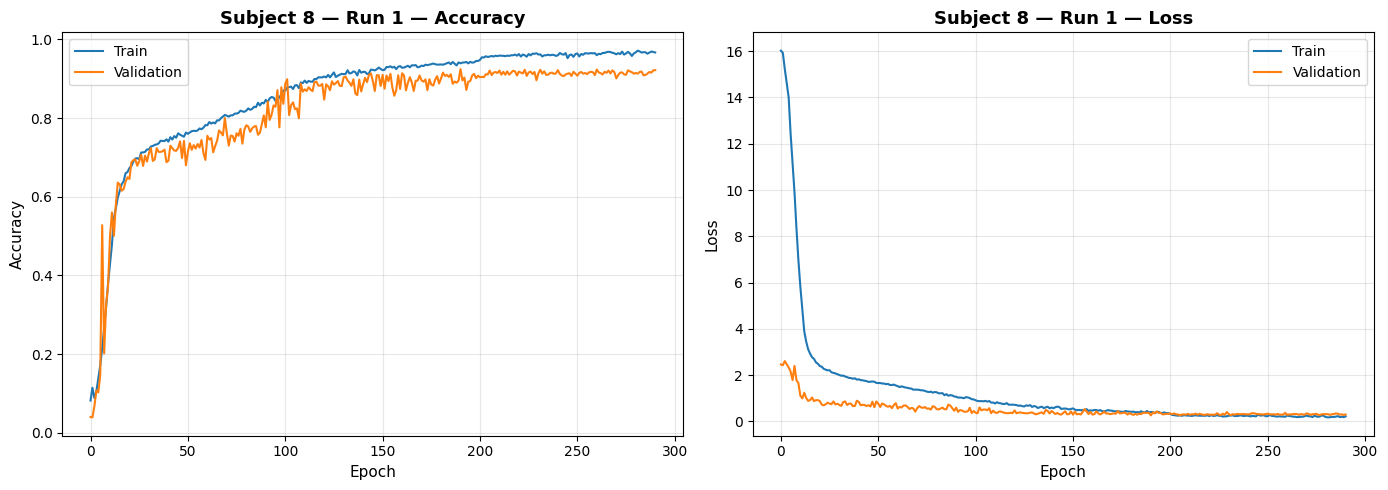


  Subject 9/10 — Leg
Fold = 9
X_train shape: (16653, 80, 7)
y_train shape: (16653,)
X_test shape: (1801, 80, 7)
y_test shape: (1801,)
Unique test labels: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11.]
  class 0: 480 windows
  class 1: 549 windows
  class 2: 488 windows
  class 3: 501 windows
  class 4: 589 windows
  class 5: 9236 windows
  class 6: 956 windows
  class 7: 171 windows
  class 8: 775 windows
  class 9: 889 windows
  class 10: 999 windows
  class 11: 1020 windows
    Epoch    2/1000  t_acc=0.0900  v_acc=0.0466  best=0.0466  lr=1.00e-04
    Epoch    3/1000  t_acc=0.1053  v_acc=0.0527  best=0.0527  lr=1.00e-04
    Epoch    4/1000  t_acc=0.0860  v_acc=0.0428  best=0.0527  lr=1.00e-04
    Epoch    6/1000  t_acc=0.1561  v_acc=0.0505  best=0.5952  lr=1.00e-04
    Epoch    8/1000  t_acc=0.2639  v_acc=0.1877  best=0.5952  lr=1.00e-04
    Epoch   10/1000  t_acc=0.3371  v_acc=0.2421  best=0.5952  lr=1.00e-04
    Epoch   12/1000  t_acc=0.4405  v_acc=0.4253  best=0.5952  lr=1.00e-

In [ ]:
# =============================================
# Train: 10-fold LOUO
# =============================================
train(dataset_conf, train_conf, results_path)


Fold = 1
X_train shape: (18408, 80, 7)
y_train shape: (18408,)
X_test shape: (1916, 80, 7)
y_test shape: (1916,)
Unique test labels: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11.]
  class 0: 584 windows
  class 1: 629 windows
  class 2: 552 windows
  class 3: 540 windows
  class 4: 657 windows
  class 5: 10152 windows
  class 6: 1036 windows
  class 7: 217 windows
  class 8: 822 windows
  class 9: 998 windows
  class 10: 1109 windows
  class 11: 1112 windows

────────────────────────────────────────────────────────────
  Raw Confusion Matrix — Subject 1 | Wrist
────────────────────────────────────────────────────────────
True/Pred           Adductor       ArmCurl    BenchPress       LegCurl      LegPress          Null        Riding  RopeSkipping       Running         Squat  StairClimber       Walking
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Ad

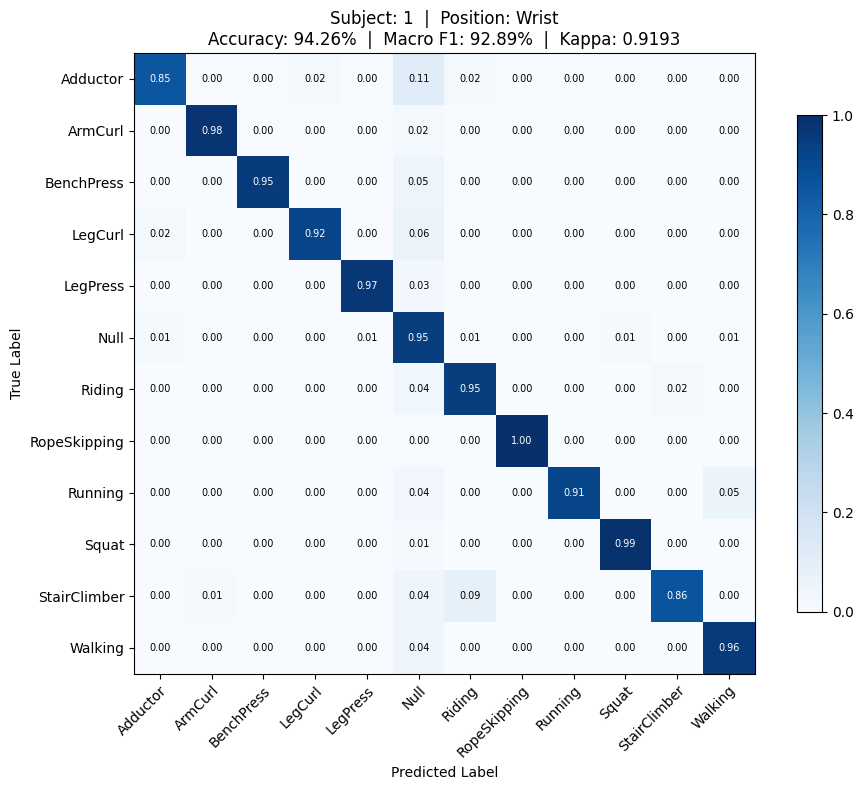


--- Classification Report (Subject 1) ---
              precision    recall  f1-score   support

    Adductor     0.7761    0.8525    0.8125        61
     ArmCurl     0.9677    0.9836    0.9756        61
  BenchPress     0.9683    0.9531    0.9606        64
     LegCurl     0.9355    0.9206    0.9280        63
    LegPress     0.9265    0.9692    0.9474        65
        Null     0.9632    0.9476    0.9553       993
      Riding     0.8525    0.9455    0.8966       110
RopeSkipping     0.8333    1.0000    0.9091        20
     Running     0.9905    0.9123    0.9498       114
       Squat     0.9389    0.9919    0.9647       124
StairClimber     0.9712    0.8632    0.9140       117
     Walking     0.9084    0.9597    0.9333       124

    accuracy                         0.9426      1916
   macro avg     0.9193    0.9416    0.9289      1916
weighted avg     0.9447    0.9426    0.9429      1916

Subject 1  best_run=1  acc=0.9426  kappa=0.9193  f1=0.9289  avg_acc=0.9426+/-0.0000
Fold =

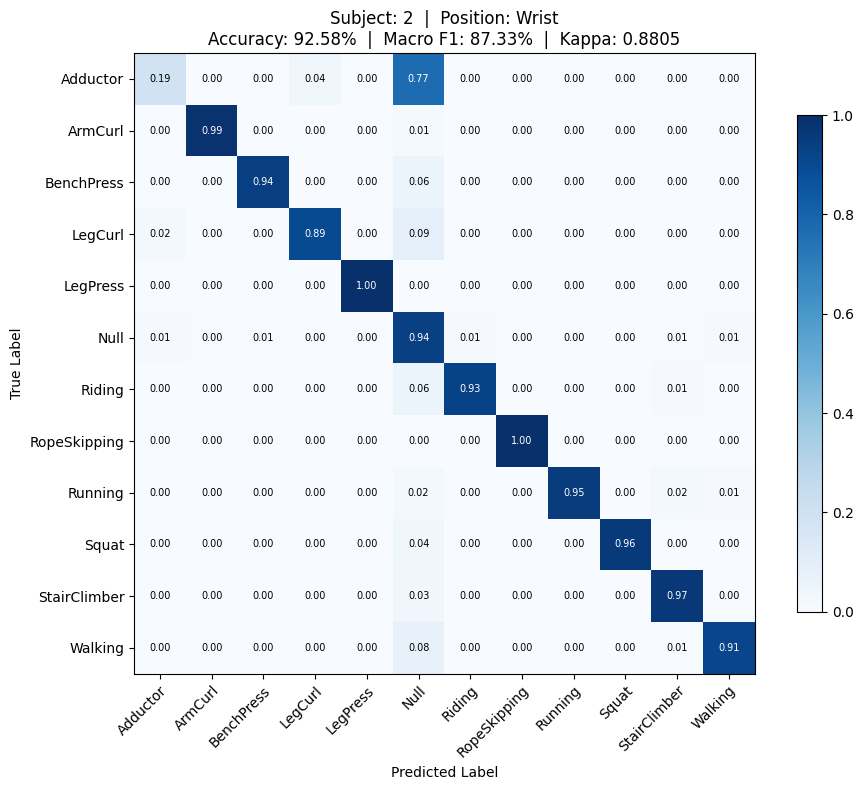


--- Classification Report (Subject 2) ---
              precision    recall  f1-score   support

    Adductor     0.4348    0.1923    0.2667        52
     ArmCurl     0.9250    0.9867    0.9548        75
  BenchPress     0.8977    0.9405    0.9186        84
     LegCurl     0.8500    0.8947    0.8718        57
    LegPress     0.9125    1.0000    0.9542        73
        Null     0.9458    0.9367    0.9412      1453
      Riding     0.8750    0.9292    0.9013       113
RopeSkipping     0.8387    1.0000    0.9123        26
     Running     1.0000    0.9528    0.9758       106
       Squat     0.9636    0.9636    0.9636       110
StairClimber     0.8939    0.9672    0.9291       122
     Walking     0.8676    0.9147    0.8906       129

    accuracy                         0.9258      2400
   macro avg     0.8671    0.8899    0.8733      2400
weighted avg     0.9210    0.9258    0.9220      2400

Subject 2  best_run=1  acc=0.9258  kappa=0.8805  f1=0.8733  avg_acc=0.9258+/-0.0000
Fold =

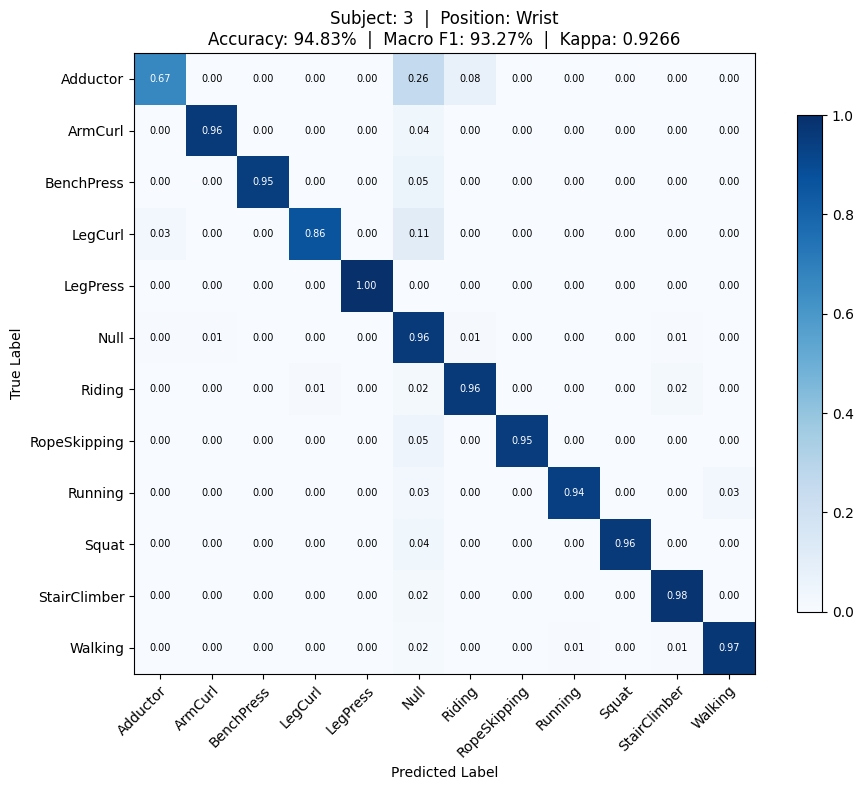


--- Classification Report (Subject 3) ---
              precision    recall  f1-score   support

    Adductor     0.8627    0.6667    0.7521        66
     ArmCurl     0.9195    0.9639    0.9412        83
  BenchPress     0.9333    0.9492    0.9412        59
     LegCurl     0.9692    0.8630    0.9130        73
    LegPress     0.9870    1.0000    0.9935        76
        Null     0.9570    0.9579    0.9575      1046
      Riding     0.8806    0.9593    0.9183       123
RopeSkipping     0.9091    0.9524    0.9302        21
     Running     0.9785    0.9381    0.9579        97
       Squat     0.9820    0.9646    0.9732       113
StairClimber     0.9297    0.9835    0.9558       121
     Walking     0.9481    0.9697    0.9588       132

    accuracy                         0.9483      2010
   macro avg     0.9381    0.9307    0.9327      2010
weighted avg     0.9483    0.9483    0.9475      2010

Subject 3  best_run=1  acc=0.9483  kappa=0.9266  f1=0.9327  avg_acc=0.9483+/-0.0000
Fold =

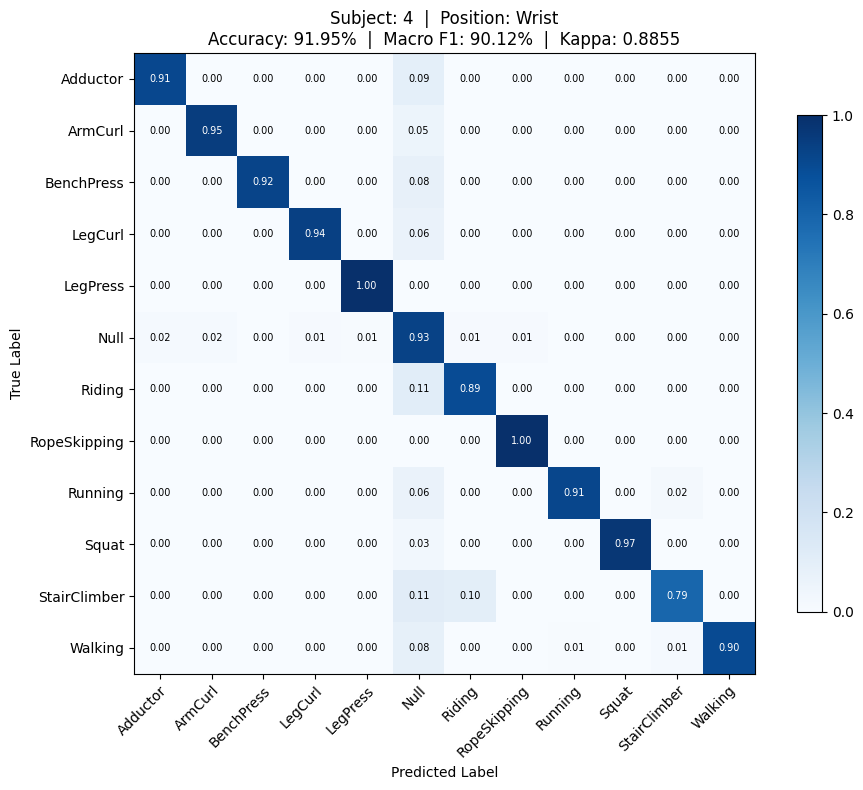


--- Classification Report (Subject 4) ---
              precision    recall  f1-score   support

    Adductor     0.7763    0.9077    0.8369        65
     ArmCurl     0.8111    0.9481    0.8743        77
  BenchPress     0.9857    0.9200    0.9517        75
     LegCurl     0.8551    0.9365    0.8939        63
    LegPress     0.9189    1.0000    0.9577        68
        Null     0.9368    0.9275    0.9321      1103
      Riding     0.7778    0.8922    0.8311       102
RopeSkipping     0.6897    1.0000    0.8163        20
     Running     0.9884    0.9140    0.9497        93
       Squat     0.9726    0.9726    0.9726       146
StairClimber     0.9603    0.7908    0.8674       153
     Walking     0.9677    0.8955    0.9302       134

    accuracy                         0.9195      2099
   macro avg     0.8867    0.9254    0.9012      2099
weighted avg     0.9243    0.9195    0.9202      2099

Subject 4  best_run=1  acc=0.9195  kappa=0.8855  f1=0.9012  avg_acc=0.9195+/-0.0000
Fold =

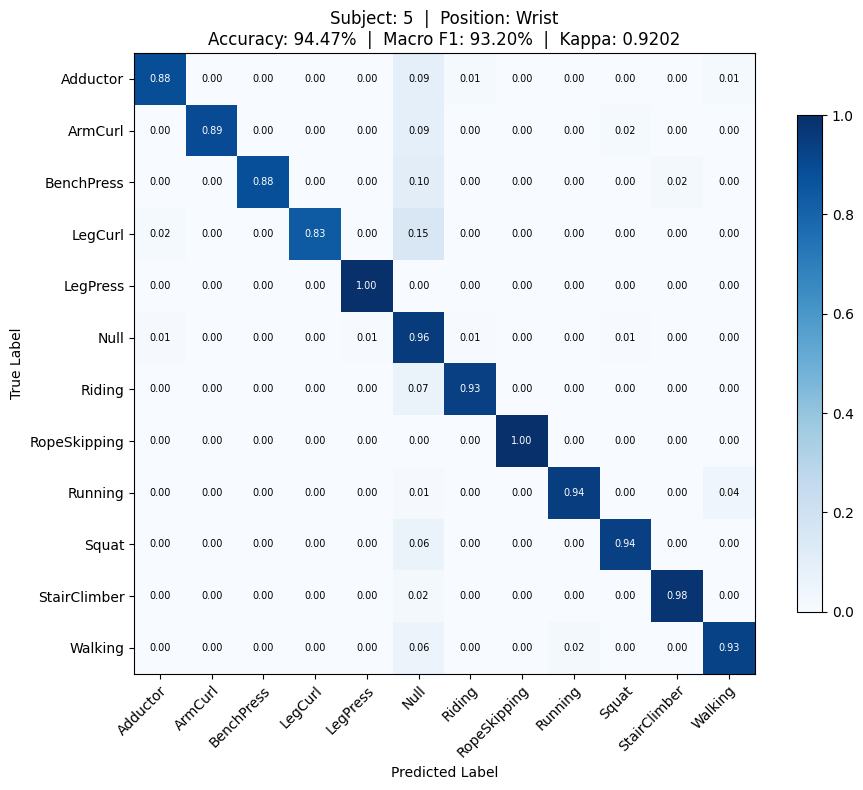


--- Classification Report (Subject 5) ---
              precision    recall  f1-score   support

    Adductor     0.8592    0.8841    0.8714        69
     ArmCurl     0.9831    0.8923    0.9355        65
  BenchPress     0.9808    0.8793    0.9273        58
     LegCurl     0.9322    0.8333    0.8800        66
    LegPress     0.9195    1.0000    0.9581        80
        Null     0.9501    0.9564    0.9533      1056
      Riding     0.9344    0.9344    0.9344       122
RopeSkipping     0.8667    1.0000    0.9286        26
     Running     0.9444    0.9444    0.9444        90
       Squat     0.9204    0.9369    0.9286       111
StairClimber     0.9754    0.9835    0.9794       121
     Walking     0.9583    0.9274    0.9426       124

    accuracy                         0.9447      1988
   macro avg     0.9354    0.9310    0.9320      1988
weighted avg     0.9452    0.9447    0.9445      1988

Subject 5  best_run=1  acc=0.9447  kappa=0.9202  f1=0.9320  avg_acc=0.9447+/-0.0000
Fold =

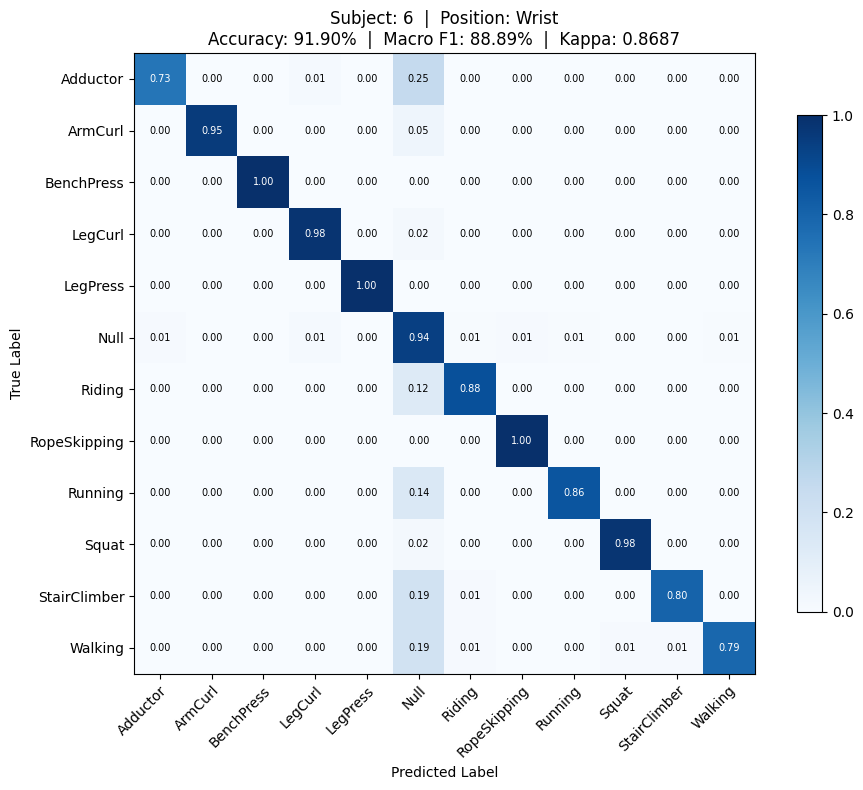


--- Classification Report (Subject 6) ---
              precision    recall  f1-score   support

    Adductor     0.7879    0.7324    0.7591        71
     ArmCurl     0.9692    0.9545    0.9618        66
  BenchPress     0.9608    1.0000    0.9800        49
     LegCurl     0.7568    0.9825    0.8550        57
    LegPress     0.9577    1.0000    0.9784        68
        Null     0.9315    0.9383    0.9349      1377
      Riding     0.9010    0.8750    0.8878       104
RopeSkipping     0.6061    1.0000    0.7547        20
     Running     0.8714    0.8592    0.8652        71
       Squat     0.9803    0.9803    0.9803       152
StairClimber     0.9417    0.8017    0.8661       121
     Walking     0.9091    0.7874    0.8439       127

    accuracy                         0.9190      2283
   macro avg     0.8811    0.9093    0.8889      2283
weighted avg     0.9216    0.9190    0.9189      2283

Subject 6  best_run=1  acc=0.9190  kappa=0.8687  f1=0.8889  avg_acc=0.9190+/-0.0000
Fold =

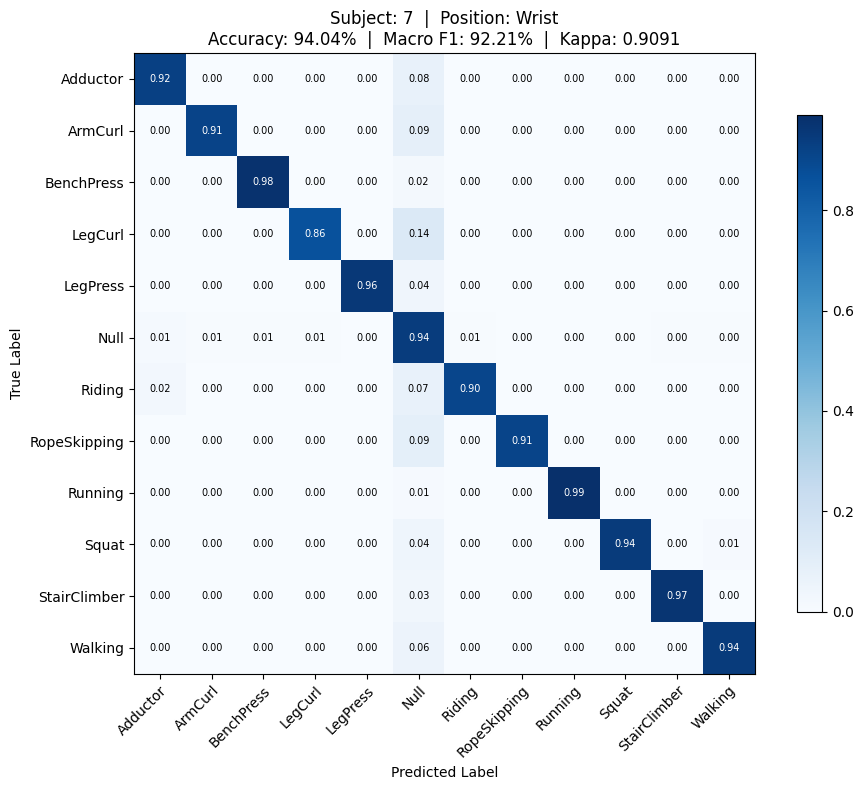


--- Classification Report (Subject 7) ---
              precision    recall  f1-score   support

    Adductor     0.7206    0.9245    0.8099        53
     ArmCurl     0.8548    0.9138    0.8833        58
  BenchPress     0.8793    0.9808    0.9273        52
     LegCurl     0.8769    0.8636    0.8702        66
    LegPress     0.9444    0.9577    0.9510        71
        Null     0.9579    0.9412    0.9495      1208
      Riding     0.9421    0.9048    0.9231       126
RopeSkipping     0.9091    0.9091    0.9091        33
     Running     0.9684    0.9892    0.9787        93
       Squat     0.9655    0.9438    0.9545        89
StairClimber     0.9516    0.9672    0.9593       122
     Walking     0.9524    0.9449    0.9486       127

    accuracy                         0.9404      2098
   macro avg     0.9103    0.9367    0.9221      2098
weighted avg     0.9425    0.9404    0.9409      2098

Subject 7  best_run=1  acc=0.9404  kappa=0.9091  f1=0.9221  avg_acc=0.9404+/-0.0000
Fold =

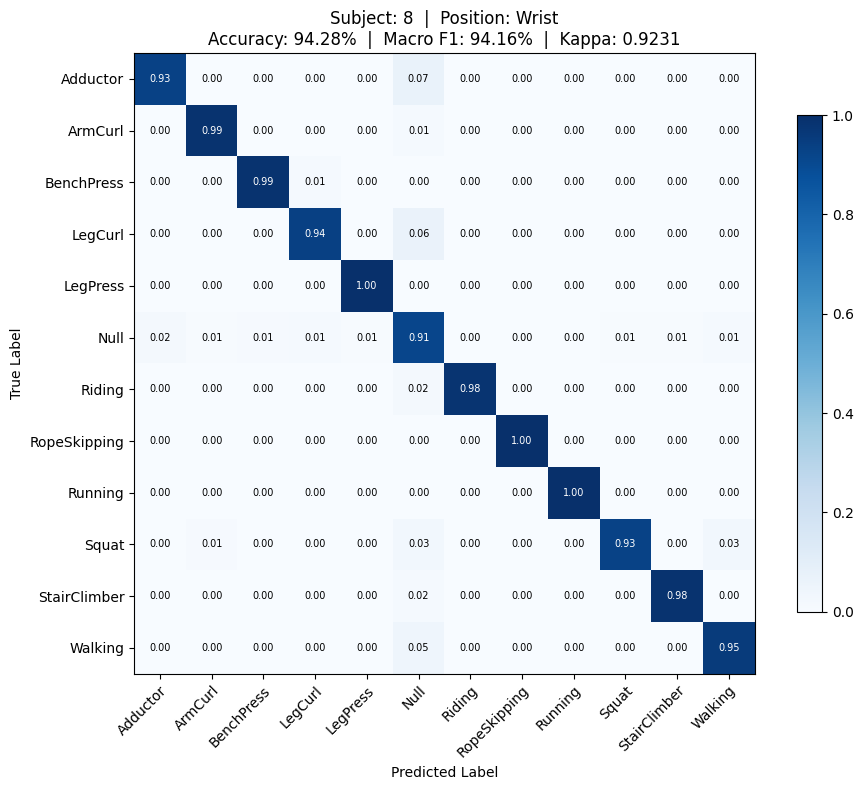


--- Classification Report (Subject 8) ---
              precision    recall  f1-score   support

    Adductor     0.8163    0.9302    0.8696        86
     ArmCurl     0.9103    0.9861    0.9467        72
  BenchPress     0.8684    0.9851    0.9231        67
     LegCurl     0.8286    0.9355    0.8788        62
    LegPress     0.9355    1.0000    0.9667        87
        Null     0.9737    0.9141    0.9429       931
      Riding     0.9756    0.9836    0.9796       122
RopeSkipping     0.9583    1.0000    0.9787        23
     Running     0.9900    1.0000    0.9950        99
       Squat     0.9485    0.9293    0.9388        99
StairClimber     0.9545    0.9844    0.9692       128
     Walking     0.8689    0.9550    0.9099       111

    accuracy                         0.9428      1887
   macro avg     0.9190    0.9669    0.9416      1887
weighted avg     0.9458    0.9428    0.9432      1887

Subject 8  best_run=1  acc=0.9428  kappa=0.9231  f1=0.9416  avg_acc=0.9428+/-0.0000
Fold =

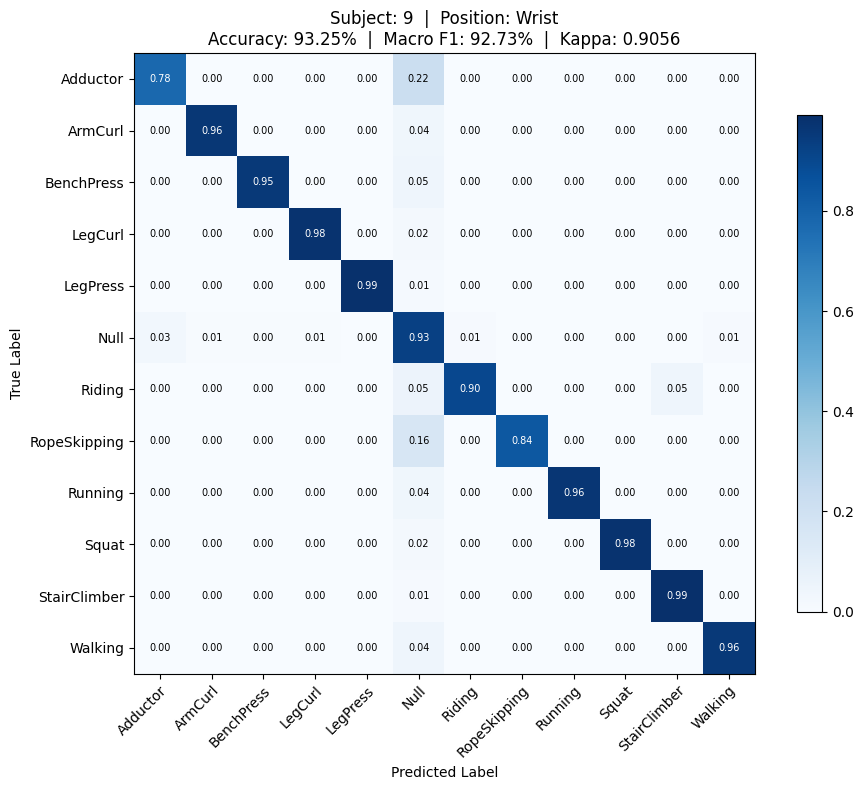


--- Classification Report (Subject 9) ---
              precision    recall  f1-score   support

    Adductor     0.6782    0.7763    0.7239        76
     ArmCurl     0.9157    0.9620    0.9383        79
  BenchPress     0.9403    0.9545    0.9474        66
     LegCurl     0.8627    0.9778    0.9167        45
    LegPress     0.9851    0.9851    0.9851        67
        Null     0.9481    0.9256    0.9367       927
      Riding     0.9252    0.9000    0.9124       110
RopeSkipping     1.0000    0.8387    0.9123        31
     Running     0.9878    0.9643    0.9759        84
       Squat     0.9659    0.9770    0.9714        87
StairClimber     0.9469    0.9907    0.9683       108
     Walking     0.9231    0.9558    0.9391       113

    accuracy                         0.9325      1793
   macro avg     0.9232    0.9340    0.9273      1793
weighted avg     0.9347    0.9325    0.9331      1793

Subject 9  best_run=1  acc=0.9325  kappa=0.9056  f1=0.9273  avg_acc=0.9325+/-0.0000
Fold =

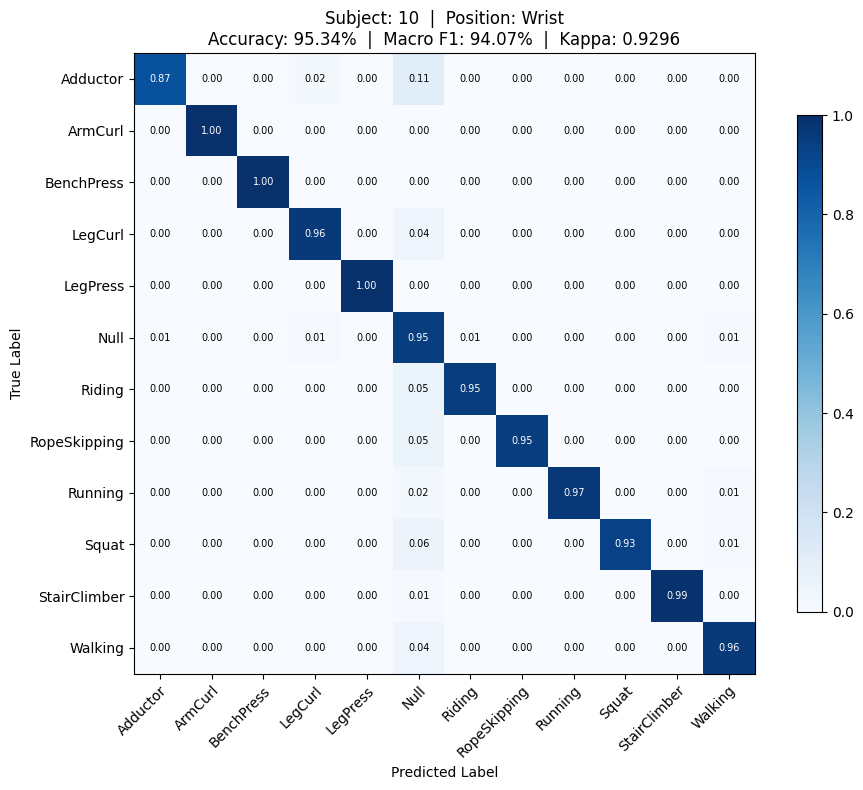


--- Classification Report (Subject 10) ---
              precision    recall  f1-score   support

    Adductor     0.8723    0.8723    0.8723        47
     ArmCurl     0.9800    1.0000    0.9899        49
  BenchPress     0.8913    1.0000    0.9425        41
     LegCurl     0.8000    0.9600    0.8727        50
    LegPress     0.9839    1.0000    0.9919        61
        Null     0.9737    0.9470    0.9602      1056
      Riding     0.9316    0.9478    0.9397       115
RopeSkipping     0.8571    0.9474    0.9000        19
     Running     0.9765    0.9651    0.9708        86
       Squat     0.9545    0.9333    0.9438        90
StairClimber     0.9658    0.9912    0.9784       114
     Walking     0.8976    0.9580    0.9268       119

    accuracy                         0.9534      1847
   macro avg     0.9237    0.9602    0.9407      1847
weighted avg     0.9551    0.9534    0.9538      1847

Subject 10  best_run=1  acc=0.9534  kappa=0.9296  f1=0.9407  avg_acc=0.9534+/-0.0000

Ave

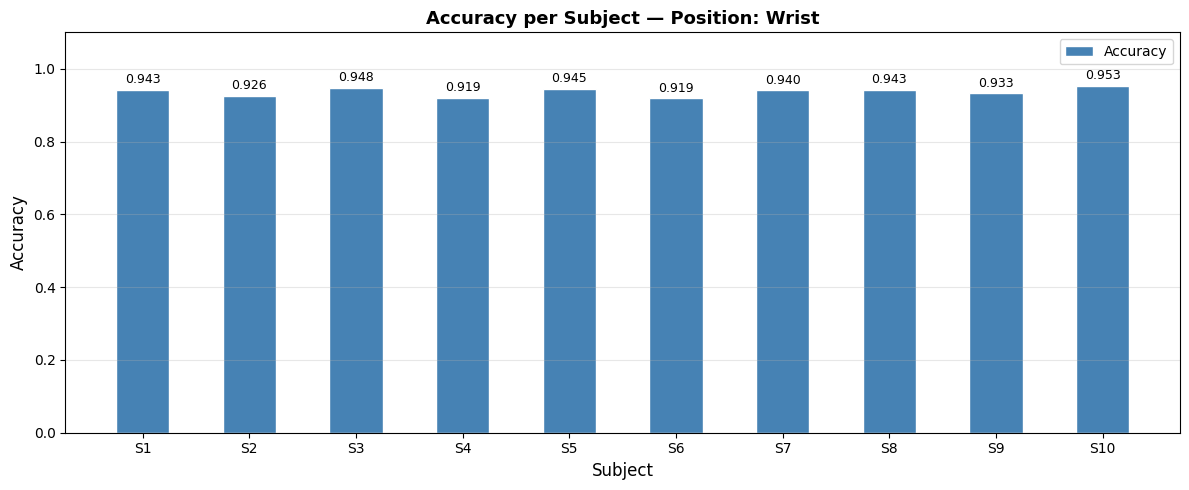

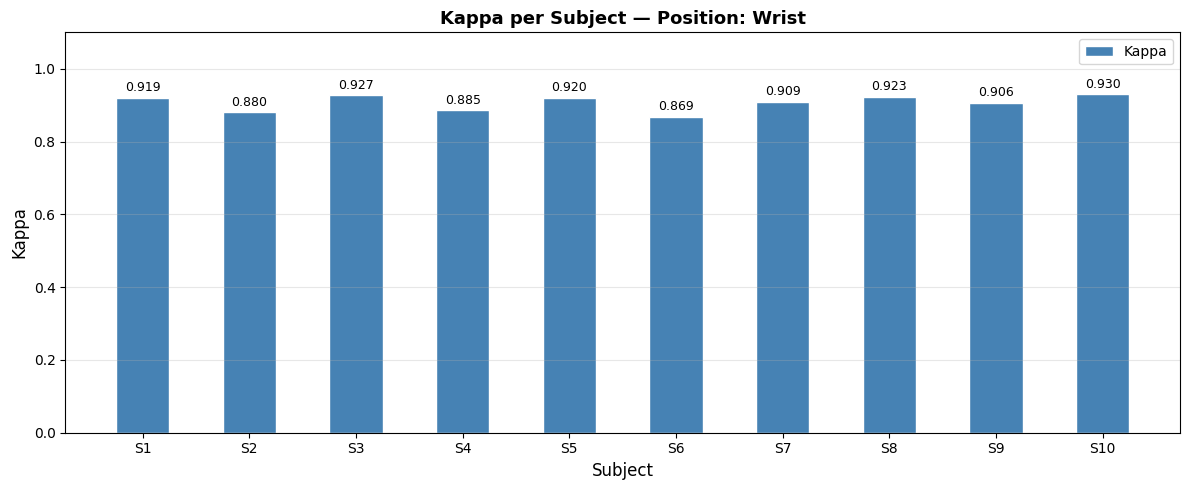

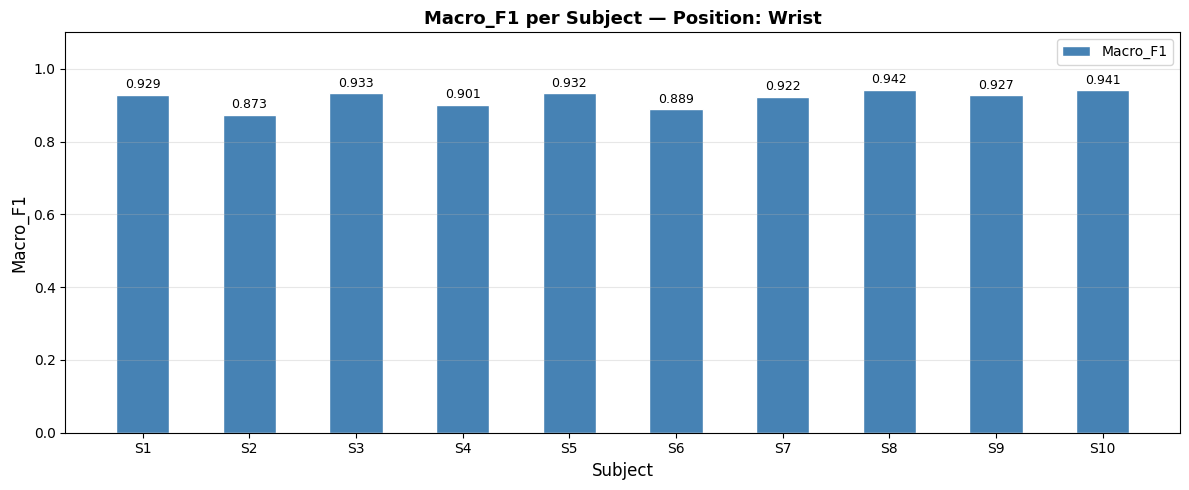


────────────────────────────────────────────────────────────
  Raw Confusion Matrix — Subject All | Wrist
────────────────────────────────────────────────────────────
True/Pred           Adductor       ArmCurl    BenchPress       LegCurl      LegPress          Null        Riding  RopeSkipping       Running         Squat  StairClimber       Walking
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Adductor                 507             0             0             5             0           126             7             0             0             0             0             1
ArmCurl                    0           657             0             0             0            27             0             0             0             1             0             0
BenchPress                 0             0           586             1             0            27  

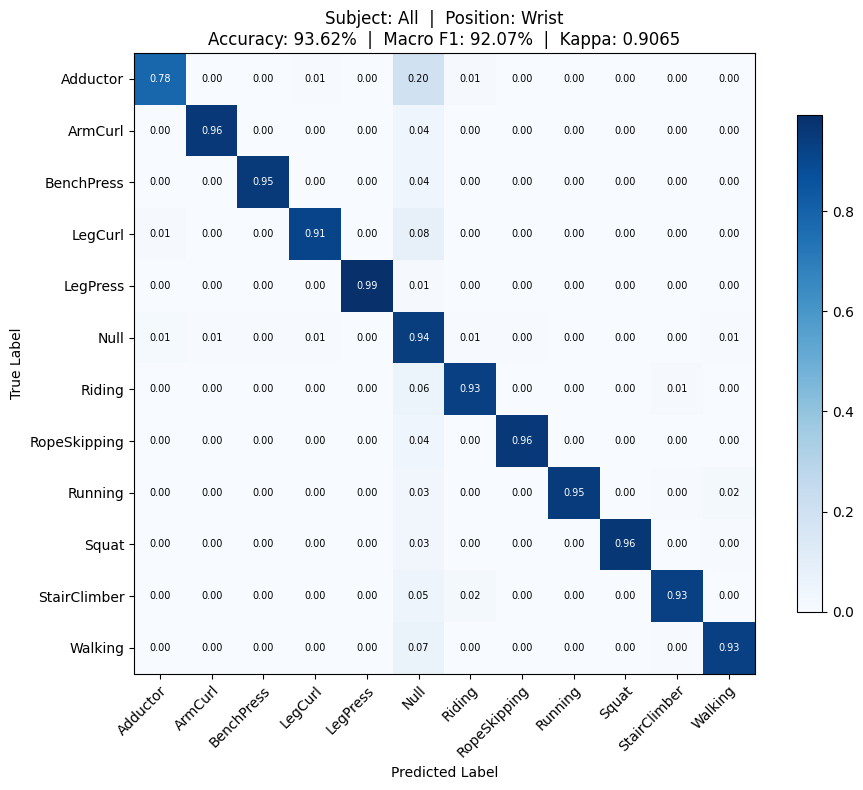


--- Classification Report (Subject All) ---
              precision    recall  f1-score   support

    Adductor     0.7752    0.7848    0.7800       646
     ArmCurl     0.9176    0.9591    0.9379       685
  BenchPress     0.9287    0.9528    0.9406       615
     LegCurl     0.8646    0.9120    0.8876       602
    LegPress     0.9454    0.9916    0.9680       716
        Null     0.9524    0.9395    0.9459     11150
      Riding     0.8995    0.9285    0.9138      1147
RopeSkipping     0.8388    0.9582    0.8945       239
     Running     0.9724    0.9453    0.9587       933
       Squat     0.9599    0.9616    0.9608      1121
StairClimber     0.9484    0.9283    0.9382      1227
     Walking     0.9199    0.9258    0.9228      1240

    accuracy                         0.9362     20321
   macro avg     0.9102    0.9323    0.9207     20321
weighted avg     0.9368    0.9362    0.9364     20321


Summary saved: /teamspace/studios/this_studio/results_wrist/evaluation_summary.csv
Subj

In [16]:
# =============================================
# Evaluate: load best models, compute metrics
# =============================================
test(dataset_conf, results_path)
